In [ ]:
# path guard: run from the repo root even if this notebook is opened inside experiments/
import os
if os.path.basename(os.getcwd()) == "experiments":
    os.chdir("..")

# Solving for the RNN that *is* the controller

*A companion to `rnn_offmanifold_finding.ipynb`. That notebook showed a trained GRU fails to
hold the win-stay/lose-shift rule off the data manifold. This one asks whether a GRU can hold
it at all, by solving for the weights instead of training them.*

## The task, before anything else

On each trial you pick one of two arms and you either win or lose. The rule that generated the data
is **win-stay/lose-shift** (WSLS): if your last choice won, pick it again; if it lost, switch. One
bit of memory is enough to follow it perfectly.

Two models were fitted to 1000 sessions of that behavior:

- a **Finite State Controller** (FSC): a handful of labelled memory states, plus a lookup table
  saying which state to move to given the last (action, outcome). Two states are enough here.
- a **GRU** (a small recurrent network, from the `tinyRNN` codebase): its memory is a short list of
  real numbers, updated by trained weights.

One more piece of vocabulary, used throughout. The data contains some situations and not others:
here the longest run of wins in a row is 33, so a run of 60 never occurs. The set of situations the
data does contain is the **data manifold**. Training can only score a model on situations it saw, so
whatever a model does **off the manifold** costs it nothing and is left entirely free.

## The question

The other notebook ended on a fork. A trained GRU reproduces win-stay/lose-shift on every trial the
data contains, and then drifts to the wrong certainty once you push it past the longest win streak
it ever saw. Two explanations survive that result:

1. A GRU this small **cannot** represent the rule. The drift is a limit of the architecture.
2. It **can**, and gradient descent failed to find the weights that do.

Training harder cannot settle this. Failing to find something is not evidence that it does not
exist. The way to settle it is to go and find it.

**It is the second one.** §2 finds weights that hold the rule exactly, at every hidden size tested,
down to a single hidden unit. So the drift in the other notebook is about how training arrived at
its weights, not about what a GRU of this size can represent. Everything after §2 is working out
what that solved network looks like inside, and why the trained one differs.

## What we do instead of training

We skip training entirely. Write down what a network would have to satisfy in order to *be* the
controller, treat those statements as equations, and solve them.

Three steps:

1. **Read the target off the fitted FSC.** The FSC's parameters already are a finite-state machine:
   a small set of memory states, a table saying which state to move to next, and a rule for which
   action each state takes. §1 prints it.
2. **Turn each requirement into an equation.** Every requirement has the form "this must equal
   that". Write both sides, subtract, and the leftover reads zero exactly when the requirement
   holds. See below.
3. **Solve.** Stack every leftover into one list and hand it to a least-squares solver, which
   hunts for the weights that zero all of them at once. It comes back missing by less than
   $10^{-8}$, and by about $6 \times 10^{-10}$ at most sizes. Nothing is trained and nothing is
   hand-tuned.

What comes out is not an approximation of the controller. It **is** the controller, written in
continuous coordinates instead of discrete ones.

### What "turn it into an equation" actually means

This is the step that sounds vague, so here it is on one real row of this notebook's own machine.

The FSC's table contains the row *"in state 0, having played arm -1 and seen a loss, move to state
1."* To hold that, the network must satisfy

$$\underbrace{\text{GRU}\big(\vec{e}_0,\; x(-1,\,\text{lose})\big)}_{\text{where one step actually lands}}
\;=\; \underbrace{\vec{e}_1}_{\text{where the table says it must land}}$$

Move everything to one side and it becomes a quantity that is zero when the requirement holds:

$$r \;=\; \text{GRU}\big(\vec{e}_0,\; x(-1,\,\text{lose})\big) \;-\; \vec{e}_1$$

That $r$ is the **residual**, and it is the only thing the solver ever looks at. At $H = 2$ both
sides are 2-number vectors, so $r$ is 2 numbers. Starting from random weights they come out as
something like

    left side   GRU(e_0, x) = [-0.0044,  0.6314]
    right side  e_1         = [ 0.1976,  0.3480]
    residual    left - right= [-0.2019,  0.2833]     <- the solver drives these to zero

Nothing about the GRU is special here. Any statement of the form "the network must do X" becomes a
number by subtracting what it must do from what it does.

**The bookkeeping.** This machine has 4 reachable table rows, 2 states needing a readout, and 1
start state, so **7 requirements**. At $H = 2$ they expand to **14 numbers** (4 transitions × 2
each, 2 readouts × 2 each, 1 start × 2) and there are **58 unknowns** available to satisfy them.
More knobs than constraints, which is why §2 also has to say *which* of the many solutions to
prefer.

## Roadmap

- §0 setup, self-contained: the GRU re-derived in plain numpy, the committed `det_init` fits
  reloaded, plot style. Nothing is trained anywhere in this notebook.
- §1 the machine: read the fitted FSC off its own parameters, and list what a network has to
  satisfy to be it.
- §2 the solver: those requirements as residuals, solved for the GRU weights and the state
  embedding jointly, at each hidden size.
- §3 verification: replay through the untouched numpy GRU, then trial by trial over 1000 real
  sessions.
- §4 head to head against the fitted FSC and the trained GRUs, ending with the off-manifold probe.
- §5 the dynamical-systems view: fixed points, eigenvalues, and the flow field.
- §6 the map between the two internal states, in both directions, and when it is invertible.
- §7 what this establishes, and what it does not.

> **Note.** The construction copies a machine, it does not discover one: the target is an FSC
> already fitted to this dataset and committed under `fitted_models/`. That FSC also has to describe
> the data. A poor fit would still solve, but it would answer a question about a machine nobody
> cares about rather than about the trained network's drift. On `det_init` the fitted FSC matches
> the data exactly, transition matrix to 0.0000 and cross-entropy 0.00000, which §4 measures rather
> than assumes; check that first on any new dataset.
>

## 0. Setup

Self-contained, in the same style as `rnn_offmanifold_finding.ipynb` §0. The GRU is re-derived in
plain numpy straight from the torch equations, so every later check runs against code the solver
never touched, and the fits are reloaded from `fitted_models/`. Nothing is trained here.

In [1]:
# --- 0.1 -- imports, path switching, pure-numpy GRU, and the loaders -----------------------
import sys, os, glob, pickle, shutil
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.func import jacrev
from scipy.optimize import least_squares, root

torch.set_default_dtype(torch.float64)      # the solver works to ~1e-10; float32 cannot

# Cross-version pandas pickle compat, same shim as the off-manifold notebook's §0.1.
import pandas.core.arrays.string_ as _pd_str
from pandas.core.arrays._mixins import NDArrayBacked as _NDArrayBacked
def _compat_string_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], np.ndarray):
        state = (state[0], state[1], {})
    return _NDArrayBacked.__setstate__(self, state)
_pd_str.StringArray.__setstate__ = _compat_string_setstate

REPO         = os.path.abspath(".")
FSC_SRC      = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING   = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    if TINYRNN_ROOT in sys.path: sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:  sys.path.insert(0, FSC_SRC)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:          sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path: sys.path.insert(0, TINYRNN_ROOT)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

DATASET      = "det_init"          # the worked case: its fitted FSC is a deterministic machine
DATASET_FILE = "datasets/wsls_actions_observations_det_init.npz"
H_LIST       = [1, 2, 3, 4]        # hidden sizes solved for, and loaded for the trained baseline
H_STAR       = 1                   # the size figures lead with: equals M, so §6's square case works
KMAX         = 80                  # off-manifold probe length, same as the other notebook

# ---- one GRU step in numpy, with the three gates exposed (torch nn.GRU equations) ----
def _sigmoid(x): return np.where(x >= 0, 1.0 / (1.0 + np.exp(-np.abs(x))),
                                 np.exp(-np.abs(x)) / (1.0 + np.exp(-np.abs(x))))
def _softmax(z):
    z = np.asarray(z, float); z = z - z.max(); e = np.exp(z); return e / e.sum()

def gru_step(h, x, P):
    """Returns (h', {reset r, update z, new n}).  h' = (1-z)*n + z*h;  z~1 hold, z~0 overwrite."""
    H  = P["H"]
    gi = P["W_ih"] @ x + P["b_ih"]
    gh = P["W_hh"] @ h + P["b_hh"]
    r  = _sigmoid(gi[:H]    + gh[:H])
    z  = _sigmoid(gi[H:2*H] + gh[H:2*H])
    n  = np.tanh( gi[2*H:]  + r * gh[2*H:])
    return (1 - z) * n + z * h, {"reset": r, "update": z, "new": n}

def rnn_action_probs(h, P):
    return _softmax(h @ P["lin_W"].T + P["lin_b"])

from contextlib import contextmanager
@contextmanager
def quiet_blas():
    """Apple's Accelerate BLAS raises spurious divide/overflow warnings inside lstsq and svd
    on inputs that are perfectly finite. Same guard the pipeline notebook uses."""
    old = np.seterr(all="ignore")
    try:
        yield
    finally:
        np.seterr(**old)

def encode_input(a, y, A, Y):
    x = np.zeros(A + Y); x[a] = 1.0; x[A + y] = 1.0; return x

def rnn_states(P, actions, observations, A, Y):
    """Teacher-forced hidden trajectory. h[t] is the state the readout saw when it had to
    predict actions[t], so h[0] is the initial state and there are T+1 rows -- the same
    convention the FSC belief filter uses below."""
    h = np.zeros(P["H"]); out = [h.copy()]
    for t in range(len(actions)):
        h, _ = gru_step(h, encode_input(actions[t], observations[t], A, Y), P)
        out.append(h.copy())
    return np.array(out)

# ---- loaders -------------------------------------------------------------------------------
def load_dataset(path, n_max=1000, seed=0):
    raw = np.load(os.path.join(REPO, path))
    ra, ro = raw["actions"], raw["observations"]
    n_use = min(n_max, ra.shape[0])
    idx = (np.arange(ra.shape[0]) if n_use == ra.shape[0]
           else np.random.default_rng(seed).choice(ra.shape[0], n_use, replace=False))
    ActSpace = np.array(sorted(set(ra[idx].flatten().tolist())))
    ObsSpace = np.array(sorted(set(ro[idx].flatten().tolist())))
    a2i = {v: i for i, v in enumerate(ActSpace)}
    o2i = {v: i for i, v in enumerate(ObsSpace)}
    sessions = [{"actions":      np.array([a2i[a] for a in ra[i]], dtype=int),
                 "observations": np.array([o2i[o] for o in ro[i]], dtype=int)} for i in idx]
    win_idx = int(np.where(ObsSpace == 1)[0][0]) if 1 in ObsSpace.tolist() else len(ObsSpace) - 1
    return dict(ActSpace=ActSpace, ObsSpace=ObsSpace, A=len(ActSpace), Y=len(ObsSpace),
                win_idx=win_idx, lose_idx=1 - win_idx, sessions=sessions)

def extract_gru_params(agent):
    net = agent.model
    p = {k: v.detach().cpu().numpy() for k, v in net.rnn.named_parameters()}
    return {"W_ih": p["weight_ih_l0"], "W_hh": p["weight_hh_l0"],
            "b_ih": p["bias_ih_l0"],   "b_hh": p["bias_hh_l0"],
            "lin_W": net.lin.weight.detach().cpu().numpy(),
            "lin_b": net.lin.bias.detach().cpu().numpy(), "H": net.hidden_dim}

def load_trained_rnns(name, A, Y, h_list):
    """The committed tinyRNN fits, best trainval loss at each hidden size."""
    _use_tinyrnn_path()
    exp  = f"exp_{name}"
    live = f"files/saved_model/{exp}"
    arch = os.path.join(REPO, "fitted_models", name, "rnn", exp)
    cwd = os.getcwd(); os.chdir("tinyRNN")
    try:
        if os.path.isdir(arch) and not os.path.isdir(live): shutil.copytree(arch, live)
        from agents import Agent
        from analyzing_experiments.analyzing_perf import select_final_rnn_perf
        _, summary, _ = select_final_rnn_perf(exp, return_dim_est=True, verbose=False)
        out = {}
        for H in h_list:
            rows = summary[summary["hidden_dim"] == H].sort_values("trainval_loss")
            if len(rows) == 0: continue
            cfg = {"agent_type": "RNN", "rnn_type": "GRU", "input_dim": A + Y, "hidden_dim": H,
                   "output_dim": A, "device": "cpu", "output_h0": True, "trainable_h0": False,
                   "readout_FC": True, "one_hot": False, "seed": 0}
            ag = Agent("RNN", config=cfg); ag.load(str(rows.iloc[0]["model_path"]))
            out[H] = extract_gru_params(ag)
        return out
    finally:
        os.chdir(cwd)

def load_fsc_machine(name):
    """The fitted FSC, read off its own parameters as a machine:
         pi(a | m)          which action each memory state takes
         g(m' | y, a, m)    where the memory moves next
         rho(m)             the start state
    plus the joint TMat the library generates from, and a check that pi * g reproduces it."""
    _use_fsc_path()
    path = glob.glob(os.path.join(REPO, f"fitted_models/{name}/fsc/best_fsc_M*.pkl"))[0]
    with open(path, "rb") as f: fsc = pickle.load(f)
    fsc.set_mode("generation")
    pi  = np.asarray(fsc.get_action_policy())        # (M, A)
    g   = np.asarray(fsc.get_memory_transitions())   # (Y, A, M, M)
    rho = np.asarray(fsc.get_rho())                  # (M,)
    Tm  = np.asarray(fsc.get_TMat())                 # (Y, M, M, A)
    err = np.abs(Tm - pi[None, :, None, :] * np.transpose(g, (0, 2, 3, 1))).max()
    assert err < 1e-9, f"pi * g does not reproduce TMat (max err {err:.2e})"
    return dict(fsc=fsc, M=int(fsc.M), pi=pi, g=g, rho=rho, TMat=Tm)

def fsc_beliefs(FSC, actions, observations):
    """Forward filter b_t(m) = P(memory = m | history up to t). b[0] = rho, so there are T+1
    rows and b[t] is the belief the FSC held when it had to choose actions[t]."""
    Tm, rho, M = FSC["TMat"], FSC["rho"], FSC["M"]
    b = rho.copy(); out = [b.copy()]
    for t in range(len(actions)):
        bn = b @ Tm[int(observations[t]), :, :, int(actions[t])]
        s = bn.sum()
        b = bn / s if s > 0 else np.ones(M) / M
        out.append(b.copy())
    return np.array(out)

D    = load_dataset(DATASET_FILE)
A, Y = D["A"], D["Y"]
WIN, LOSE = D["win_idx"], D["lose_idx"]
FSC  = load_fsc_machine(DATASET)
M    = FSC["M"]
TRAINED = load_trained_rnns(DATASET, A, Y, H_LIST)
_use_fsc_path()

print(f"dataset {DATASET}: {len(D['sessions'])} sessions x {len(D['sessions'][0]['actions'])} trials")
print(f"  actions {D['ActSpace'].tolist()} (indices 0..{A-1}), observations {D['ObsSpace'].tolist()} "
      f"-> win = index {WIN}, lose = index {LOSE}")
print(f"  fitted FSC: M = {M}")
print(f"  trained GRUs loaded at H = {sorted(TRAINED)}")

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 801.76it/s]


dataset det_init: 1000 sessions x 200 trials
  actions [-1, 1] (indices 0..1), observations [0, 1] -> win = index 1, lose = index 0
  fitted FSC: M = 2
  trained GRUs loaded at H = [1, 2, 3, 4]


In [2]:
# --- 0.2 -- plot style, matching the off-manifold notebook so figures read side by side -----
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
})
C_FSC     = "#111111"    # the FSC: the reference, not a series hue
C_SOLVED  = "#1baf7a"    # green  -- the solved GRU
C_TRAINED = "#eb6834"    # orange -- the trained GRU
C_ARM     = {0: "#2a78d6", 1: "#eb6834"}
C_RULE    = "0.35"
C_STATE   = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a", 3: "#a35bd1"}
SHADE     = "#8a8a86"

ACT_NAME = {i: f"a={D['ActSpace'][i]:+d}" for i in range(A)}
OBS_NAME = {WIN: "win", LOSE: "lose"}

# longest run of wins anywhere in the data: the edge of the region training ever saw
_runs = []
for s in D["sessions"]:
    r = 0
    for v in s["observations"]:
        r = r + 1 if v == WIN else 0
        _runs.append(r)
MAX_STREAK = int(max(_runs))

def shade_indata(ax, label=True):
    ax.axvspan(0, MAX_STREAK, color=SHADE, alpha=0.13, lw=0, zorder=0)
    if label:
        ax.text(MAX_STREAK, 0.02, f" longest streak\n in data (k={MAX_STREAK})", fontsize=7.5,
                color="0.4", ha="left", va="bottom", transform=ax.get_xaxis_transform())

print(f"Style ready. Longest win streak in {DATASET}: {MAX_STREAK} trials.")

Style ready. Longest win streak in det_init: 33 trials.


## 1. The machine we are asking the network to be

§1 only reads and lists. Nothing is solved here; §2 does that.

**The FSC.** A machine with two memory states. Each state plays one fixed action. After it plays and
sees the outcome, a lookup table says which state to move to next. That is all of it: no counting,
no accumulation, no notion of "more evidence". §1.1 prints the three arrays that hold it.

| array | shape | what it says |
|---|---|---|
| $\pi(a \mid m)$ | $(M, A)$ | which action state $m$ plays |
| $g(m' \mid y, a, m)$ | $(Y, A, M, M)$ | which state to move to after playing $a$ and seeing $y$ |
| $\rho(m)$ | $(M,)$ | which state it starts in |

**The one thing that needs deciding.** The FSC's states are names. A GRU's memory is a vector. So
something has to pick which vector means "state 0". Call it $\vec{e}_m$, and collect them as the
columns of $E$. §2 solves for $E$ alongside the weights, because some placements make the conditions
below satisfiable and others do not.

**The condition, once $E$ exists.** One GRU step from $\vec{e}_m$ under input $(a, y)$ must land
*on* $\vec{e}_{g(y,a,m)}$, not near it. That exactness is the whole difference from the trained
network: the trained one resembles this machine, a solved one is it.

**§1.2 prints the list**: one condition per reachable row of the table, one readout per state, one
for the start state. Rows the machine can never reach are skipped, because the FSC's fit left
whatever the optimizer happened to leave in them and matching that would be matching noise.

In [3]:
# --- 1.1 -- the fitted FSC, read off its own parameters as a machine -----------------------
pi, g, rho = FSC["pi"], FSC["g"], FSC["rho"]

print(f"M = {M} memory states, A = {A} actions, Y = {Y} observations\n")
print("pi(a | m)   -- which action each memory state takes")
for m in range(M):
    print(f"   m={m}: " + "   ".join(f"P({ACT_NAME[a]}) = {pi[m, a]:.4f}" for a in range(A)))

print(f"\nrho(m)      -- the start state:  {np.round(rho, 4).tolist()}"
      f"   (starts in m={int(rho.argmax())})")

print("\ng(m' | y, a, m)   -- where the memory moves next")
print("   rows marked UNREACHABLE are (state, action) pairs the policy never takes, so the")
print("   fitted numbers there are unconstrained and carry no meaning")
for m in range(M):
    for a in range(A):
        reachable = pi[m, a] > 1e-6
        for y in range(Y):
            row = g[y, a, m]
            tag = f"-> m={int(row.argmax())}" if reachable else "UNREACHABLE"
            print(f"   from m={m} taking {ACT_NAME[a]:<6} then {OBS_NAME[y]:<5}: "
                  f"{np.round(row, 4).tolist()}  {tag}")

det = np.abs(np.stack([g[y, a, m] for m in range(M) for a in range(A)
                       if pi[m, a] > 1e-6 for y in range(Y)]).max(axis=1) - 1).max()
print(f"\nEvery reachable transition row is one-hot to within {det:.2e},")
print(f"and every pi row is one-hot to within {np.abs(pi.max(axis=1) - 1).max():.2e}.")
print("So this fitted controller is a DETERMINISTIC machine: memory state is a function of\n"
      "history, and the action is a function of the memory state. That is what makes an exact\n"
      "solve possible below. A stochastic controller would be solvable too, but the target\n"
      "would be a distribution rather than a point.")

M = 2 memory states, A = 2 actions, Y = 2 observations

pi(a | m)   -- which action each memory state takes
   m=0: P(a=-1) = 1.0000   P(a=+1) = 0.0000
   m=1: P(a=-1) = 0.0000   P(a=+1) = 1.0000

rho(m)      -- the start state:  [1.0, 0.0]   (starts in m=0)

g(m' | y, a, m)   -- where the memory moves next
   rows marked UNREACHABLE are (state, action) pairs the policy never takes, so the
   fitted numbers there are unconstrained and carry no meaning
   from m=0 taking a=-1   then lose : [0.0, 1.0]  -> m=1
   from m=0 taking a=-1   then win  : [1.0, 0.0]  -> m=0
   from m=0 taking a=+1   then lose : [0.0, 1.0]  UNREACHABLE
   from m=0 taking a=+1   then win  : [0.1163, 0.8837]  UNREACHABLE
   from m=1 taking a=-1   then lose : [1.0, 0.0]  UNREACHABLE
   from m=1 taking a=-1   then win  : [1.0, 0.0]  UNREACHABLE
   from m=1 taking a=+1   then lose : [1.0, 0.0]  -> m=0
   from m=1 taking a=+1   then win  : [0.0, 1.0]  -> m=1

Every reachable transition row is one-hot to within 0.00e+00,

In [4]:
# --- 1.2 -- the requirement list: what a network must satisfy to BE this machine -----------
def machine_constraints(pi, g, rho, p_min=1e-6):
    """Every (state, action, observation) triple the machine can actually be in, plus the
    start state. Pairs with pi(a | m) = 0 are skipped: the machine never takes that action
    from that state, so the fitted g row there is unconstrained and means nothing."""
    M, A = pi.shape; Y = g.shape[0]
    trans = [(m, a, y, g[y, a, m]) for m in range(M) for a in range(A)
             if pi[m, a] > p_min for y in range(Y)]
    return trans, int(np.argmax(rho))

TRANS, M0 = machine_constraints(pi, g, rho)

print(f"{len(TRANS)} transition requirements (of {M * A * Y} triples; "
      f"{M * A * Y - len(TRANS)} are unreachable and imposed on nothing):\n")
for (m, a, y, gn) in TRANS:
    print(f"   in m={m}, took {ACT_NAME[a]:<6}, saw {OBS_NAME[y]:<5}  ->  must land in "
          f"m={int(gn.argmax())}")
print(f"\n{M} readout requirements: the network's action distribution at the vector standing")
print(f"   for m must equal pi(. | m).")
print(f"\n1 start requirement: the vector standing for m={M0} must be the network's initial")
print(f"   hidden state, which tinyRNN fixes at h0 = 0 (trainable_h0 = False).")
print("\nThat last one is not decoration. It is the requirement the network needs in order to")
print("get the FIRST trial of a session right, and it is what forces the map in §6 to be")
print("affine rather than linear: one memory state is pinned to the origin of hidden space.")

4 transition requirements (of 8 triples; 4 are unreachable and imposed on nothing):

   in m=0, took a=-1  , saw lose   ->  must land in m=1
   in m=0, took a=-1  , saw win    ->  must land in m=0
   in m=1, took a=+1  , saw lose   ->  must land in m=0
   in m=1, took a=+1  , saw win    ->  must land in m=1

2 readout requirements: the network's action distribution at the vector standing
   for m must equal pi(. | m).

1 start requirement: the vector standing for m=0 must be the network's initial
   hidden state, which tinyRNN fixes at h0 = 0 (trainable_h0 = False).

That last one is not decoration. It is the requirement the network needs in order to
get the FIRST trial of a session right, and it is what forces the map in §6 to be
affine rather than linear: one memory state is pinned to the origin of hidden space.


## 2. Solving for the weights

§1 produced a list of conditions. §2 finds a network that satisfies them.

**The two unknowns.** The GRU's weights, and $E$, the choice of which vector means which memory
state. Both are solved at once, since a placement of the states and a set of weights only work
together.

**The conditions.** With $x(a,y)$ the one-hot input encoding and $\text{GRU}(\vec{h}, \vec{x})$ one
step:

$$
\underbrace{\text{GRU}(\vec{e}_m,\, x(a,y)) \;=\; \vec{e}_{\,g(y,a,m)}}_{\text{transitions, for every reachable } (m,a,y)}
\qquad
\underbrace{\text{softmax}(W_{\text{lin}}\vec{e}_m + b_{\text{lin}}) \;=\; \pi(\cdot \mid m)}_{\text{readout, for every } m}
\qquad
\underbrace{\vec{e}_{m_0} \;=\; \vec{0}}_{\text{start}}
$$

Land where the table says, play what the state says, start where tinyRNN starts. The first block
carries the weight: it demands the table hold as an identity in hidden space, not on average and not
only on the trials that occur. That is precisely what the trained network fails.

**One softening.** $\pi$ is a hard one-hot, and a softmax reaches that only with infinite weights.
So the target is pulled `conf` $= 10^{-3}$ off the vertex:

$$\tilde{\pi}(\cdot \mid m) = (1 - \texttt{conf})\,\pi(\cdot \mid m) + \tfrac{\texttt{conf}}{A}$$

This is the only approximation in the construction. `conf` is how certain the network is allowed to
be, and it sets the $0.9995$ ceiling that shows up in §4.

**How it is solved.** Each condition becomes a number that reads zero when it holds, and a solver
hunts for unknowns that zero all of them at once. Two things shape that search:

- It is **iterative**. Sigmoids and a $\tanh$ sit inside a GRU step, so there is no formula to solve
  directly; the solver has to step toward an answer.
- There are **more unknowns than conditions**, so many networks satisfy the list rather than one.
  The solver runs from several random starts and the smallest-weight answer is kept, which makes the
  result reproducible instead of arbitrary.

§2.1 holds the code, §2.2 reports the worst violation at each hidden size.

> **Not the same operation as §6.** Here the network does not exist yet and is built from §1's list.
> In §6 the network already exists and is never modified; a translation is fitted on top of it from
> data, and that translation's error is the result. §2 builds, §6 measures.

In [5]:
# --- 2.1 -- the solver ---------------------------------------------------------------------
# Takes a machine (pi, g, rho) and a hidden size, returns GRU weights plus the embedding E.
# Nothing about win-stay/lose-shift is hardcoded: the machine is an argument.

def _shapes(H, A, Y, M):
    return [("W_ih", (3*H, A+Y)), ("b_ih", (3*H,)), ("W_hh", (3*H, H)), ("b_hh", (3*H,)),
            ("lin_W", (A, H)), ("lin_b", (A,)), ("E", (H, M))]

def _unpack(theta, H, A, Y, M):
    """One flat parameter vector -> the named blocks. Used by both the residual and the caller,
    so the packing order can never disagree between them."""
    out, i = {}, 0
    for k, sh in _shapes(H, A, Y, M):
        n = int(np.prod(sh)); out[k] = theta[i:i+n].reshape(sh); i += n
    return out

def solve_gru_for_fsc(pi, g, rho, H, conf=1e-3, pin_h0=True, lam=3e-2, restarts=5,
                      seed=0, exact_tol=1e-8, E_fixed=None, verbose=True):
    """Solve for GRU weights and an embedding E such that the GRU IS the machine (pi, g, rho).

    Returns (P, E, residual) where P is a weight dict in the same format as a trained fit, E has
    the memory states as columns, and residual is the largest violation of any requirement.

    `conf`    how far the target policy is pulled off the vertices; the network's certainty cap.
    `pin_h0`  require the start state to sit at h = 0, which is where tinyRNN starts every
              session (trainable_h0 = False). Turning it off frees the embedding but gives up
              the first trial of each session; §6.3 uses both settings.
    `restarts` independent random starts. Among those that reach the exactness bar, the one with
              the smallest weights is kept, so the answer is a small solution rather than the
              first one found.
    `E_fixed` pin the embedding to a chosen matrix instead of solving for it, and solve only for
              the weights. §6.4 uses this to force a square invertible embedding."""
    M, A = pi.shape; Y = g.shape[0]
    trans, m0 = machine_constraints(pi, g, rho)
    K = len(trans)
    npar = sum(int(np.prod(sh)) for _, sh in _shapes(H, A, Y, M))

    # every requirement, precomputed as tensors so the residual is a handful of matrix ops
    m_idx = torch.tensor([t[0] for t in trans])
    Xb = torch.zeros(K, A + Y)
    for i, (m, a, y, _) in enumerate(trans):
        Xb[i, a] = 1.0; Xb[i, A + y] = 1.0
    Gn      = torch.tensor(np.stack([t[3] for t in trans]))            # (K, M) target state
    log_tgt = torch.tensor(np.log((1.0 - conf) * pi + conf / A))       # (M, A) softened policy

    E_pin = None if E_fixed is None else torch.tensor(np.asarray(E_fixed, float))

    def residual_t(theta, lam_t):
        P = _unpack(theta, H, A, Y, M)
        E = P["E"] if E_pin is None else E_pin
        Hb = E[:, m_idx].T                                             # (K, H) starting states
        gi = Xb @ P["W_ih"].T + P["b_ih"]
        gh = Hb @ P["W_hh"].T + P["b_hh"]
        r  = torch.sigmoid(gi[:, :H]     + gh[:, :H])
        z  = torch.sigmoid(gi[:, H:2*H]  + gh[:, H:2*H])
        n  = torch.tanh(   gi[:, 2*H:]   + r * gh[:, 2*H:])
        r_trans = ((1 - z) * n + z * Hb) - Gn @ E.T                     # one GRU step vs target
        r_read  = torch.log_softmax(E.T @ P["lin_W"].T + P["lin_b"], 1) - log_tgt
        parts = [r_trans.reshape(-1), r_read.reshape(-1)]
        if E_pin is not None:
            parts.append(P["E"].reshape(-1) - E_pin.reshape(-1))        # park the unused block
        if pin_h0:
            parts.append(E[:, m0])                                      # start state at the origin
        parts.append(lam_t * theta)                                     # ridge / tiebreaker
        return torch.cat(parts)

    jac_fn = jacrev(residual_t)                       # exact Jacobian, not finite differences
    def f(th, lv): return residual_t(torch.tensor(th), torch.tensor(lv)).numpy()
    def J(th, lv): return jac_fn(torch.tensor(th), torch.tensor(lv)).numpy()

    kw = dict(jac=J, method="lm", xtol=1e-15, ftol=1e-15, gtol=1e-15, max_nfev=5000)
    best, rng = None, np.random.default_rng(seed)
    for k in range(restarts):
        th = 0.5 * rng.standard_normal(npar)
        th = least_squares(f, th, args=(lam,),   **kw).x       # pass 1: a small-weight solution
        th = least_squares(f, th, args=(1e-12,), **kw).x       # pass 2: an exact one
        res = float(np.abs(f(th, 0.0)).max()); nrm = float(np.linalg.norm(th))
        key = (res > exact_tol, nrm)                           # exact first, then smallest weights
        if verbose:
            print(f"     restart {k}: max requirement violation {res:.2e}   ||params|| {nrm:6.2f}")
        if best is None or key < best[0]:
            best = (key, res, th)
    _, res, th = best
    P = {k: v.numpy().copy() for k, v in _unpack(torch.tensor(th), H, A, Y, M).items()}
    E = P.pop("E"); P["H"] = H
    if E_fixed is not None:
        E = np.asarray(E_fixed, float)
    return P, E, res

print("Solver defined. Nothing about this task is baked in: pass a different (pi, g, rho) and\n"
      "it solves for a different machine.")

Solver defined. Nothing about this task is baked in: pass a different (pi, g, rho) and
it solves for a different machine.


In [6]:
# --- 2.2 -- solve at every hidden size ------------------------------------------------------
import time
SOLVED, EMB, RESID = {}, {}, {}
for H in H_LIST:
    t0 = time.time()
    print(f"H = {H}:")
    P, E, res = solve_gru_for_fsc(pi, g, rho, H, verbose=False)
    SOLVED[H], EMB[H], RESID[H] = P, E, res
    print(f"   kept: violation {res:.2e}   ({time.time() - t0:.1f}s)\n")

print(f"{'H':>3}  {'max violation':>14}  {'max |weight|':>13}   embedded states e_m (columns of E)")
for H in H_LIST:
    P, E = SOLVED[H], EMB[H]
    mw = max(np.abs(v).max() for k, v in P.items() if k != "H")
    cols = "   ".join(f"e_{m}={np.round(E[:, m], 4).tolist()}" for m in range(M))
    print(f"{H:>3}  {RESID[H]:>14.2e}  {mw:>13.3f}   {cols}")

print("\nEvery size solves. The worst requirement violation is under 1e-8 at every size and about")
print("6e-10 for H >= 2; H = 1 is the loosest of them. That is a solution rather than a fit: no")
print("residual error is left to attribute to optimization difficulty.")
print("\nNote the embeddings. The solver was free to place the states anywhere in R^H and put")
print("them on a LINE through the origin every time, using one direction and leaving the rest")
print("of hidden space unused. It was not told to. With M = 2 states, one direction is all the")
print("machine needs, and the small-weight preference in pass 1 does the rest. §6 turns this")
print("into the exact condition for the map between the two models to be invertible.")

H = 1:
   kept: violation 7.63e-09   (12.1s)

H = 2:
   kept: violation 5.97e-10   (13.9s)

H = 3:
   kept: violation 6.90e-10   (19.3s)

H = 4:
   kept: violation 5.94e-10   (34.6s)

  H   max violation   max |weight|   embedded states e_m (columns of E)
  1        7.63e-09         11.313   e_0=[-0.0]   e_1=[0.7841]
  2        5.97e-10         11.846   e_0=[0.0, -0.0]   e_1=[0.945, -0.0]
  3        6.90e-10         11.636   e_0=[0.0, -0.0, -0.0]   e_1=[0.0, -0.917, 0.0]
  4        5.94e-10         11.849   e_0=[0.0, -0.0, -0.0, 0.0]   e_1=[0.945, -0.0, -0.0, -0.0]

Every size solves. The worst requirement violation is under 1e-8 at every size and about
6e-10 for H >= 2; H = 1 is the loosest of them. That is a solution rather than a fit: no
residual error is left to attribute to optimization difficulty.

Note the embeddings. The solver was free to place the states anywhere in R^H and put
them on a LINE through the origin every time, using one direction and leaving the rest
of hidden sp

In [7]:
# --- 2.3 -- the solved weights, in full, and the one row that does the work -------------------
# Printed so the construction can be checked by hand or lifted into another notebook. Rows of
# W_ih / W_hh / b_ih / b_hh are grouped [reset | update | new], H rows each, as torch orders them.
def show_weights(P, E, title):
    H = P["H"]
    print(f"--- {title}  (H = {H}) " + "-" * max(0, 60 - len(title)))
    names = ([f"r{i}" for i in range(H)] + [f"z{i}" for i in range(H)] + [f"n{i}" for i in range(H)])
    print(f"   {'gate':>5}  {'W_ih (act0 act1 | obs0 obs1)':<34}  {'b_ih':>9}  "
          f"{'W_hh':<22}  {'b_hh':>9}")
    for i, nm in enumerate(names):
        print(f"   {nm:>5}  {str(np.round(P['W_ih'][i], 4).tolist()):<34}  "
              f"{P['b_ih'][i]:>9.4f}  {str(np.round(P['W_hh'][i], 4).tolist()):<22}  "
              f"{P['b_hh'][i]:>9.4f}")
    print(f"   readout  lin_W = {np.round(P['lin_W'], 4).tolist()}   lin_b = {np.round(P['lin_b'], 4).tolist()}")
    print(f"   embedding E = {np.round(E, 6).tolist()}\n")

for H in (1, H_STAR):
    show_weights(SOLVED[H], EMB[H], f"solved GRU, {DATASET}")

# The mechanism is legible in one row. z is the update gate: z = 1 keeps h unchanged, z = 0
# overwrites it. Its input weights are ordered [action_0, action_1 | obs_0, obs_1], so the last
# two entries are what the OUTCOME does to the gate.
_z = SOLVED[H_STAR]["W_ih"][H_STAR:2 * H_STAR][0]
print(f"Read the z0 row of the H = {H_STAR} solve: W_ih = {np.round(_z, 2).tolist()}")
print(f"   the two observation weights are {_z[A]:+.1f} (lose) and {_z[A + 1]:+.1f} (win), a swing")
print(f"   of {abs(_z[A + 1] - _z[A]):.0f} between the two outcomes, dwarfing everything else in the row.")
print("   Winning drives the gate to 1, which is 'keep h exactly'. Losing drives it to 0, which is")
print("   'overwrite h'. That is win-stay/lose-shift implemented as hold/reset, and §5 measures it")
print("   as an identity map under winning inputs. Nobody told the solver to do this.")
print("\nThe larger sizes are in SOLVED[H] / EMB[H]; they are the same solution with extra rows")
print("of zeros, which §5 and §6 make sense of.")

--- solved GRU, det_init  (H = 1) ----------------------------------------
    gate  W_ih (act0 act1 | obs0 obs1)             b_ih  W_hh                         b_hh
      r0  [0.1956, 0.0381, 0.2768, -0.0431]      0.2338  [0.0367]                   0.2338
      z0  [2.1158, 0.5153, -8.682, 11.313]       2.6309  [0.4879]                   2.6309
      n0  [1.9241, -0.9682, -0.0926, 1.0475]     0.9558  [-0.705]                   0.6134
   readout  lin_W = [[-9.7867], [9.5993]]   lin_b = [3.7028, -3.8976]
   embedding E = [[-0.0, 0.784113]]

--- solved GRU, det_init  (H = 1) ----------------------------------------
    gate  W_ih (act0 act1 | obs0 obs1)             b_ih  W_hh                         b_hh
      r0  [0.1956, 0.0381, 0.2768, -0.0431]      0.2338  [0.0367]                   0.2338
      z0  [2.1158, 0.5153, -8.682, 11.313]       2.6309  [0.4879]                   2.6309
      n0  [1.9241, -0.9682, -0.0926, 1.0475]     0.9558  [-0.705]                   0.6134
   readout  lin

## 3. Verification

The solver's own residual proves nothing: it is reporting the quantity it was told to minimize. §3
checks the solved weights independently, by replaying them through `gru_step` from §0.1 (the plain
numpy GRU, untouched by the solver) and by running them over real sessions.

Two levels, weakest to strongest:

- **3.2** every reachable transition, replayed in numpy and laid out as a table: from this state,
  under this input, where does the network actually land, and is it where the FSC's table says?
- **3.3** whole real sessions. Run the FSC's belief filter and the solved GRU side by side over the
  same 1000 sessions of `det_init`, driven by the same real choices and outcomes, and compare them
  trial by trial on both the internal state and the predicted action.

3.3 is the one that matters. 3.2 confirms the solve on the handful of points it was solved against;
3.3 confirms the network behaves as the controller on 200,000 trials of data that neither of them
ever saw.

In [8]:
# --- 3.2 -- every requirement replayed, then the full transition table ----------------------
# First the numeric check that §3.1 used to make on its own: replay each requirement through
# gru_step (the plain numpy GRU, untouched by the solver) and report the largest violation.
# It is a weak check by design, since these are the same points the solver optimized; its job is
# to catch a mismatch between the solver's GRU and this notebook's. §3.3 is the real test.
print("Every requirement replayed through the plain numpy gru_step. Worst violation found:\n")
print(f"{'H':>3}  {'transitions':>12}  {'readout':>10}  {'start state':>12}")
CHECK = {}
for _H in H_LIST:
    _P, _E = SOLVED[_H], EMB[_H]
    _t = max(np.abs(gru_step(_E[:, m], encode_input(a, y, A, Y), _P)[0] - _E @ gn).max()
             for (m, a, y, gn) in TRANS)
    _r = max(np.abs(rnn_action_probs(_E[:, m], _P) - ((1 - 1e-3) * pi[m] + 1e-3 / A)).max()
             for m in range(M))
    CHECK[_H] = (_t, _r, np.abs(_E[:, M0]).max())
    print(f"{_H:>3}  {_t:>12.2e}  {_r:>10.2e}  {np.abs(_E[:, M0]).max():>12.2e}")
print("   transitions: how far one step lands from where the machine says it should")
print("   readout:     how far the action distribution is from the softened target policy")
print("   start state: how far e_m0 sits from h = 0, where tinyRNN starts every session")
print()

# Every reachable (state, action, observation), with the hidden vector before and after and the
# action the readout picks. This is the machine's table, produced by the network rather than
# looked up.
P, E = SOLVED[H_STAR], EMB[H_STAR]      # H_STAR set in §0.1
print(f"Solved GRU, H = {H_STAR}. Each row is one step of gru_step() from an embedded state.\n")
print(f"   {'from':>5}  {'action':>7}  {'outcome':>8}  {'h before':>18}  {'h after':>18}  "
      f"{'lands in':>8}  {'FSC says':>8}  {'P(next action)':>16}")
for (m, a, y, gn) in TRANS:
    h0v = E[:, m]
    h1v, _ = gru_step(h0v, encode_input(a, y, A, Y), P)
    lands = int(np.argmin(np.linalg.norm(E - h1v[:, None], axis=0)))
    p_next = rnn_action_probs(h1v, P)
    def _z(v):                      # -0.0 is still zero, but printing it looks like a defect
        r = np.round(v, 4); r[r == 0] = 0.0; return r.tolist()
    print(f"   m={m:<3}  {ACT_NAME[a]:>7}  {OBS_NAME[y]:>8}  {str(_z(h0v)):>18}  "
          f"{str(_z(h1v)):>18}  {'m='+str(lands):>8}  {'m='+str(int(gn.argmax())):>8}  "
          f"{str(_z(p_next)):>16}")
print("\nRead the last three columns together: the network lands where the FSC says, and the")
print("action it then picks is the action that state takes. This IS win-stay/lose-shift, and")
print("nowhere in the solve was that phrase used -- it came out of the fitted FSC's own table.")

Every requirement replayed through the plain numpy gru_step. Worst violation found:

  H   transitions     readout   start state
  1      7.63e-09    7.58e-14      1.29e-16
  2      5.97e-10    3.37e-15      3.88e-19
  3      6.90e-10    4.74e-15      4.61e-19
  4      5.94e-10    4.67e-15      3.84e-19
   transitions: how far one step lands from where the machine says it should
   readout:     how far the action distribution is from the softened target policy
   start state: how far e_m0 sits from h = 0, where tinyRNN starts every session

Solved GRU, H = 1. Each row is one step of gru_step() from an embedded state.

    from   action   outcome            h before             h after  lands in  FSC says    P(next action)
   m=0       a=-1      lose               [0.0]            [0.7841]       m=1       m=1  [0.0005, 0.9995]
   m=0       a=-1       win               [0.0]               [0.0]       m=0       m=0  [0.9995, 0.0005]
   m=1       a=+1      lose            [0.7841]         

In [9]:
# --- 3.3 -- whole real sessions: FSC belief filter vs solved GRU, trial by trial ------------
# Both models are driven by the same real (action, observation) sequences, so any disagreement
# is a disagreement between the models rather than between two samples.
def compare_on_sessions(P, E, sessions):
    """Per trial: does the GRU sit at the embedding of the state the FSC is in, and does it
    predict the action the FSC's policy would take?"""
    d_state, agree_act, n = [], 0, 0
    for s in sessions:
        b = fsc_beliefs(FSC, s["actions"], s["observations"])     # (T+1, M)
        h = rnn_states(P, s["actions"], s["observations"], A, Y)  # (T+1, H)
        d_state.append(np.linalg.norm(h - b @ E.T, axis=1))       # h_t vs E @ b_t
        p_rnn = np.array([rnn_action_probs(hv, P) for hv in h])
        p_fsc = b @ pi
        agree_act += int((p_rnn.argmax(1) == p_fsc.argmax(1)).sum()); n += len(p_rnn)
    d = np.concatenate(d_state)
    return d, agree_act / n

def compare_trained(P, sessions):
    """The trained nets have no embedding, so the fairest stand-in is the BEST affine map from
    hidden state to FSC belief, fitted by least squares on this very data. Whatever it leaves
    over is error no linear readout of this network could have removed."""
    Xall, Ball = [], []
    for s in sessions:
        Xall.append(rnn_states(P, s["actions"], s["observations"], A, Y))
        Ball.append(fsc_beliefs(FSC, s["actions"], s["observations"]))
    Xall = np.concatenate(Xall); Ball = np.concatenate(Ball)
    Xa = np.hstack([Xall, np.ones((len(Xall), 1))])
    with quiet_blas():
        W, *_ = np.linalg.lstsq(Xa, Ball, rcond=None)
        resid = np.abs(Ball - Xa @ W)
        p_rnn = np.array([rnn_action_probs(hv, P) for hv in Xall])
        acc = (p_rnn.argmax(1) == (Ball @ pi).argmax(1)).mean()
    return resid.mean(), resid.max(), acc

SESS = D["sessions"]
print(f"Over all {len(SESS)} sessions x {len(SESS[0]['actions'])} trials of {DATASET}.")
print("How far each network's hidden state is from standing for the FSC's memory state:\n")
print(f"{'model':>12}  {'mean gap':>10}  {'worst gap':>10}  {'measured against':>22}  {'same action':>12}")
_sol, _tra = [], []
for H in H_LIST:
    d, acc = compare_on_sessions(SOLVED[H], EMB[H], SESS)
    _sol.append((d.mean(), d.max()))
    print(f"{'solved H='+str(H):>12}  {d.mean():>10.2e}  {d.max():>10.2e}  "
          f"{'its own embedding E':>22}  {acc:>12.4%}")
for H in H_LIST:
    mn, mx, acc = compare_trained(TRAINED[H], SESS[:200])
    _tra.append((mn, mx))
    print(f"{'trained H='+str(H):>12}  {mn:>10.2e}  {mx:>10.2e}  "
          f"{'best-fit affine map':>22}  {acc:>12.4%}")
# stated as a range rather than one round figure: the gap depends on which pair you compare
_lo = np.log10(min(t[0] for t in _tra) / max(s_[0] for s_ in _sol))
_hi = np.log10(max(t[0] for t in _tra) / min(s_[0] for s_ in _sol))

print("\nThe two halves are not the same measurement, which is the point. The solved networks are")
print("compared against the embedding the construction already fixed; nothing is fitted. The")
print("trained ones have no embedding, so they get the BEST affine map that exists, found by least")
print(f"squares on this same data. Even handed that advantage they sit {_lo:.0f} to {_hi:.0f} orders of")
print("magnitude worse, and §6.2 repeats it properly on held-out sessions with the same result.")
print("\nRead the last column against the rest. Every model picks the FSC's action on 100% of")
print("trials, so behavior separates nothing here; only the internal state does. For the solved")
print("networks the hidden state is not merely decodable to the FSC's memory state, it IS the")
print("embedding of it, every trial. §4 and §6 take those two facts apart.")

Over all 1000 sessions x 200 trials of det_init.
How far each network's hidden state is from standing for the FSC's memory state:

       model    mean gap   worst gap        measured against   same action
  solved H=1    7.07e-09    2.52e-07     its own embedding E     100.0000%
  solved H=2    1.15e-09    3.93e-08     its own embedding E     100.0000%
  solved H=3    1.39e-09    4.34e-08     its own embedding E     100.0000%
  solved H=4    1.15e-09    3.91e-08     its own embedding E     100.0000%
 trained H=1    3.29e-02    4.67e-01     best-fit affine map     100.0000%
 trained H=2    2.31e-02    3.98e-01     best-fit affine map     100.0000%
 trained H=3    1.12e-02    3.81e-01     best-fit affine map     100.0000%
 trained H=4    3.24e-02    3.33e-01     best-fit affine map     100.0000%

The two halves are not the same measurement, which is the point. The solved networks are
compared against the embedding the construction already fixed; nothing is fitted. The
trained ones have 

## 4. Head to head: solved GRU, fitted FSC, trained GRU

§3 established the solved network is the controller. §4 puts all three models through the same
measurements, ending with the one that broke the trained network.

The order is deliberate. §4.1 to §4.3 stay on the data manifold: predictive likelihood, the action
transition matrix, the win-stay/lose-shift rates. These are the measurements normally used to claim
a network learned a rule, and on all three of them every model looks the same. That is the point.
§4.4 leaves the manifold and they stop looking the same.

In [10]:
# --- 4.1 to 4.3 -- the three standard on-manifold measurements, in one cell ------------------
# All three are computed teacher-forced: each model is fed the REAL history and scored on the
# action it predicts next, so any difference is between models rather than between samples.
#   cross-entropy        how surprised the model is by the action actually taken (0 = never)
#   transition matrix    P(repeat the previous action | previous action, previous outcome)
#   win-stay/lose-shift  the same matrix read in the two numbers the task is described by
def _ce(step_probs, sessions):
    """Mean -log P(action actually taken), and the same on trial 0 alone."""
    tot, n, first = 0.0, 0, []
    for s in sessions:
        p = np.clip(step_probs(s), 1e-12, 1.0)
        ll = -np.log(p[np.arange(len(s["actions"])), s["actions"]])
        tot += ll.sum(); n += len(ll); first.append(ll[0])
    return tot / n, float(np.mean(first))

def probs_fsc(s):
    return fsc_beliefs(FSC, s["actions"], s["observations"])[:-1] @ pi
def probs_rnn(P):
    return lambda s: np.array([rnn_action_probs(hv, P)
                               for hv in rnn_states(P, s["actions"], s["observations"], A, Y)[:-1]])

# kept under these names because §6.4 and §7.1 call them
def ce_fsc(sessions):     return _ce(probs_fsc, sessions)
def ce_rnn(P, sessions):  return _ce(probs_rnn(P), sessions)

def transition_matrix_data(sessions):
    num = np.zeros((A, Y, A)); den = np.zeros((A, Y))
    for s in sessions:
        a, o = s["actions"], s["observations"]
        for t in range(1, len(a)):
            num[a[t-1], o[t-1], a[t]] += 1; den[a[t-1], o[t-1]] += 1
    return num / np.maximum(den, 1)[:, :, None]

def transition_matrix_model(step_probs, sessions):
    num = np.zeros((A, Y, A)); den = np.zeros((A, Y))
    for s in sessions:
        a, o = s["actions"], s["observations"]
        p = step_probs(s)
        for t in range(1, len(a)):
            num[a[t-1], o[t-1]] += p[t]; den[a[t-1], o[t-1]] += 1
    return num / np.maximum(den, 1)[:, :, None]

def rates_from_matrix(T):
    """The transition matrix read as the two numbers the task is usually described by."""
    return (float(np.mean([T[a, WIN, a] for a in range(A)])),
            float(np.mean([1 - T[a, LOSE, a] for a in range(A)])))

MODEL_LIST = ([("FSC", probs_fsc)]
              + [(f"solved H={H}", probs_rnn(SOLVED[H])) for H in H_LIST]
              + [(f"trained H={H}", probs_rnn(TRAINED[H])) for H in H_LIST])
TM = {"data": transition_matrix_data(SESS)}
CE_TAB = {}
for _nm, _sp in MODEL_LIST:
    TM[_nm] = transition_matrix_model(_sp, SESS); CE_TAB[_nm] = _ce(_sp, SESS)

sw_d, sl_d = rates_from_matrix(TM["data"])
print("Teacher-forced on the real sessions. The data row is the target; lower CE is better.\n")
print(f"{'model':>12}  {'CE/trial':>9}  {'CE trial0':>10}  {'P(stay|win)':>12}  {'P(shift|lose)':>14}")
print(f"{'data':>12}  {'--':>9}  {'--':>10}  {sw_d:>12.5f}  {sl_d:>14.5f}")
for _nm, _ in MODEL_LIST:
    sw, sl = rates_from_matrix(TM[_nm]); c, c0 = CE_TAB[_nm]
    print(f"{_nm:>12}  {c:>9.5f}  {c0:>10.5f}  {sw:>12.5f}  {sl:>14.5f}")

print(f"\nCE floor implied by the certainty cap (conf = 1e-3): {-np.log(1 - 1e-3 / 2):.5f} per trial.")
print("The solved networks sit exactly on it, so their whole gap to the FSC is the cap §2 chose.")
print("Note that trained H=4 scores BELOW that floor. Uncapped, it is allowed to be more confident")
print("than the solved networks are, and on this data that pays. Cross-entropy therefore ranks a")
print("trained network above the one that provably IS the controller.")
print("\nTrial 0 is broken out because it is the only trial with no history. The solved networks")
print("score the same there as anywhere, because their start point IS h0 = 0; the trained ones")
print("are far worse, because their h0 stands for nothing in particular.")

print("\nThe same agreement, per condition. P(repeat the previous action):\n")
print(f"{'model':>12}  " + "  ".join(f"{ACT_NAME[a]+','+OBS_NAME[y]:>10}"
                                     for a in range(A) for y in range(Y)) + f"  {'max dev':>8}")
for _k in ["data"] + [nm for nm, _ in MODEL_LIST]:
    T = TM[_k]
    cells = [T[a, y, a] for a in range(A) for y in range(Y)]
    dev = max(abs(T[a, y, a] - TM["data"][a, y, a]) for a in range(A) for y in range(Y))
    print(f"{_k:>12}  " + "  ".join(f"{c:>10.4f}" for c in cells)
          + (f"  {'--':>8}" if _k == "data" else f"  {dev:>8.4f}"))

print("\nEvery model reproduces the data in all four conditions, to within 0.004. These three")
print("measurements are the ones normally used to claim a network learned a rule, and not one of")
print("them separates a network that IS the controller from one that merely predicts like it.")
print("§4.4 is where they come apart.")

Teacher-forced on the real sessions. The data row is the target; lower CE is better.

       model   CE/trial   CE trial0   P(stay|win)   P(shift|lose)
        data         --          --       1.00000         1.00000
         FSC    0.00000     0.00000       1.00000         1.00000
  solved H=1    0.00050     0.00050       0.99950         0.99950
  solved H=2    0.00050     0.00050       0.99950         0.99950
  solved H=3    0.00050     0.00050       0.99950         0.99950
  solved H=4    0.00050     0.00050       0.99950         0.99950
 trained H=1    0.00343     0.28143       0.99797         0.99802
 trained H=2    0.00102     0.01527       0.99954         0.99838
 trained H=3    0.00227     0.17083       0.99872         0.99841
 trained H=4    0.00029     0.03063       0.99988         0.99984

CE floor implied by the certainty cap (conf = 1e-3): 0.00050 per trial.
The solved networks sit exactly on it, so their whole gap to the FSC is the cap §2 chose.
Note that trained H=4 sco

### 4.4 The probe that separates them

The measurement from `rnn_offmanifold_finding.ipynb` §2, applied to all three models: hand the model
the same trial over and over, "you chose arm $a$, and you won", for $k$ steps, and read off its
confidence that it will stay.

**Only a flat line is correct.** More winning evidence cannot reduce the commitment to staying, so
flatness is the test and height is not. The FSC never moves, its transition being a table lookup
with no notion of accumulated evidence. The trained GRU holds the line inside the streak lengths the
data contains, then slides. The solved GRU is the test of whether that slide was necessary; its
ceiling is $0.9995$, the cap §2 chose, not a drift.

**Where each model starts.** Every model begins in a state that plays the arm being probed. Starting
elsewhere feeds the machine an input it can never receive, where no model has a defined right answer
and the curve scores nothing; §7 covers what that case does show. The trained nets have no memory
states, so they start at $h_0 = 0$ and are simply told they played this arm and won. Read them from
$k = 1$, since their $k = 0$ value is an untouched $h_0$ that stands for nothing in particular.

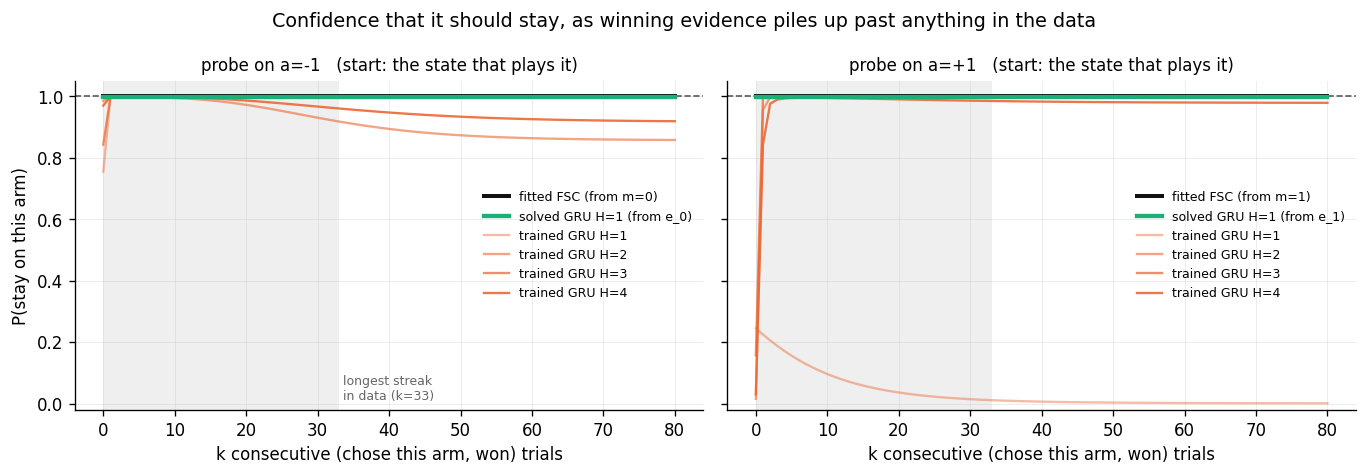

                 model  k=0     k=10    k=33    k=40    k=80  
-- probe on a=-1, started from the state that plays it --
            fitted FSC  1.0000  1.0000  1.0000  1.0000  1.0000   drift(k>=1) 0.0e+00
        solved GRU H=1  0.9995  0.9995  0.9995  0.9995  0.9995   drift(k>=1) 5.8e-09
       trained GRU H=1  0.7547  0.9996  0.9996  0.9996  0.9996   drift(k>=1) 3.8e-03
       trained GRU H=2  0.9848  0.9949  0.9181  0.8940  0.8580   drift(k>=1) 1.4e-01
       trained GRU H=3  0.8430  0.9995  0.9996  0.9996  0.9996   drift(k>=1) 1.5e-03
       trained GRU H=4  0.9698  0.9974  0.9605  0.9474  0.9190   drift(k>=1) 8.1e-02
-- probe on a=+1, started from the state that plays it --
            fitted FSC  1.0000  1.0000  1.0000  1.0000  1.0000   drift(k>=1) 0.0e+00
        solved GRU H=1  0.9995  0.9995  0.9995  0.9995  0.9995   drift(k>=1) 1.3e-10
       trained GRU H=1  0.2453  0.0960  0.0109  0.0062  0.0007   drift(k>=1) 2.2e-01
       trained GRU H=2  0.0152  0.9992  0.9992  0.9992  

In [11]:
# --- 4.4 -- the off-manifold probe, all three models -----------------------------------------
# Every model is started in a state consistent with having just played the arm being probed.
# Without that the probe is not a win-stay test at all: driving a model that is about to play
# arm A with "you played arm B and won" is an input the machine can never receive, so no model
# has a defined right answer and the curve scores nothing. See §7 for what that case does show.
def rnn_probe(P, a0, y_idx, kmax=KMAX, h_start=None):
    """P(stay on a0) after k consecutive (chose a0, saw y_idx) trials."""
    x = encode_input(a0, y_idx, A, Y)
    h = np.zeros(P["H"]) if h_start is None else h_start.copy()
    out = [rnn_action_probs(h, P)[a0]]
    for _ in range(kmax):
        h, _ = gru_step(h, x, P)
        out.append(rnn_action_probs(h, P)[a0])
    return np.array(out)

def fsc_probe(a0, y_idx, kmax=KMAX, b_start=None):
    b = rho.copy() if b_start is None else b_start.copy()
    out = [float((b @ pi)[a0])]
    for _ in range(kmax):
        bn = b @ FSC["TMat"][y_idx, :, :, a0]; s = bn.sum()
        b = bn / s if s > 0 else b
        out.append(float((b @ pi)[a0]))
    return np.array(out)

def playing_state(a0):
    """The memory state whose policy plays a0. That is where a win-stay probe on a0 belongs."""
    return int(np.argmax(pi[:, a0]))

def probe_row(a0):
    """(FSC, solved, {H: trained}) curves for arm a0, each from its proper starting state.
    The trained nets have no memory states, so they start at h0 = 0; from k = 1 onward they
    have been told they played a0 and won, which is the closest thing available."""
    m_a = playing_state(a0)
    u = np.zeros(M); u[m_a] = 1.0
    return (fsc_probe(a0, WIN, b_start=u),
            rnn_probe(SOLVED[H_STAR], a0, WIN, h_start=EMB[H_STAR][:, m_a]),
            {H: rnn_probe(TRAINED[H], a0, WIN) for H in H_LIST})

kk = np.arange(KMAX + 1)
fig, axes = plt.subplots(1, A, figsize=(11.5, 4.0), sharey=True)
for a0 in range(A):
    ax = axes[a0]; m_a = playing_state(a0)
    c_fsc, c_solved, c_trained = probe_row(a0)
    shade_indata(ax, label=(a0 == 0))
    ax.axhline(1.0, color=C_RULE, ls="--", lw=1.0)
    ax.plot(kk, c_fsc, color=C_FSC, lw=2.4, label=f"fitted FSC (from m={m_a})", zorder=5)
    ax.plot(kk, c_solved, color=C_SOLVED, lw=2.6, label=f"solved GRU H={H_STAR} (from e_{m_a})",
            zorder=6)
    for H in H_LIST:
        ax.plot(kk, c_trained[H], color=C_TRAINED, lw=1.4,
                alpha=0.45 + 0.15 * H_LIST.index(H), label=f"trained GRU H={H}")
    ax.set_xlabel("k consecutive (chose this arm, won) trials")
    ax.set_title(f"probe on {ACT_NAME[a0]}   (start: the state that plays it)", fontsize=10)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=7.5, loc="center right")
axes[0].set_ylabel("P(stay on this arm)")
fig.suptitle("Confidence that it should stay, as winning evidence piles up past anything in the data",
             fontsize=11.5)
plt.tight_layout(); plt.show()

KS = (0, 10, MAX_STREAK, 40, KMAX)
print(f"{'model':>22}  " + "  ".join(f"k={k:<4}" for k in KS))
for a0 in range(A):
    c_fsc, c_solved, c_trained = probe_row(a0)
    print(f"-- probe on {ACT_NAME[a0]}, started from the state that plays it --")
    for nm, cur in ([("fitted FSC", c_fsc), (f"solved GRU H={H_STAR}", c_solved)] +
                    [(f"trained GRU H={H}", c_trained[H]) for H in H_LIST]):
        # drift measured from k = 1: the k = 0 point is an untouched h0 for the trained
        # nets, so including it would report their start-state offset as if it were drift.
        print(f"{nm:>22}  " + "  ".join(f"{cur[k]:<6.4f}" for k in KS)
              + f"   drift(k>=1) {abs(cur[1:].max() - cur[1:].min()):.1e}")

print("\nThe drift column is the whole measurement: win-stay says more winning evidence cannot")
print("reduce the commitment to staying, so the ONLY correct curve is a flat one. Height is not")
print("the test. The solved network is flat to ~1e-9 on both arms, at the 1 - conf/2 = 0.9995")
print("ceiling §2 chose. It is not flat because 80 steps is too few to see a drift: §5 shows the")
print("winning maps hold the state exactly, so it is flat for any k whatsoever.")
# Summarize the drift column from the numbers rather than asserting a pattern: which arm a
# trained fit breaks on is set by where training happened to land, so it varies with size and
# with dataset and is not a property of the task.
_dr = lambda c: abs(c[1:].max() - c[1:].min())
_solved = [_dr(probe_row(a0)[1]) for a0 in range(A)]
_tr = {H: [_dr(probe_row(a0)[2][H]) for a0 in range(A)] for H in H_LIST}
_tr_all = [v for vs in _tr.values() for v in vs]
print(f"\nDrift, solved network:  {min(_solved):.1e} to {max(_solved):.1e}")
print(f"Drift, trained networks: {min(_tr_all):.1e} to {max(_tr_all):.1e}")
print(f"   that is {np.log10(min(_tr_all) / max(_solved)):.0f} to "
      f"{np.log10(max(_tr_all) / max(_solved)):.0f} orders of magnitude above the solved worst.")
print("\nPer trained fit, and per arm (' -- ' = holds, i.e. drift < 1e-2):")
for H in H_LIST:
    print(f"   H={H}: " + "   ".join(
        f"{ACT_NAME[a0]}: {_tr[H][a0]:.1e}{'' if _tr[H][a0] >= 1e-2 else '  --'}"
        for a0 in range(A)))
print("\nWhich arm a trained fit breaks on is not fixed: on this dataset some sizes slide on one")
print("arm, one slides on both and one holds both. That is the point of the other notebook's §5,")
print("where the breaking arm flips with hidden size. What does not vary is that the solved")
print("network holds every arm at every size, by construction rather than by luck.")
print("\nDrift is measured from k = 1 on purpose: the trained nets have no memory states, so their")
print("k = 0 value is an untouched h0 that stands for nothing in particular, and counting the jump")
print("off it would report a start-state offset as drift.")

## 5. The dynamical-systems view

§4.4 read one number off the network. §5 looks at the machinery that produced it.

**The framing.** Hold the input fixed at one $(a, y)$ pair and the GRU stops depending on anything
external. What is left is a map from hidden space to itself: give it a point, it hands back another
point. There are $A \times Y$ such maps, and the network's whole behavior is those maps passing a
single point between them as trials arrive. Same framing as `fsc_tinyrnn_pipeline_ts.ipynb` §5.2c.

**Part of the answer is known in advance**, which turns the figures into a check rather than an
exploration. §2's requirement $\text{GRU}(\vec{e}_m, x(a,y)) = \vec{e}_{g(y,a,m)}$ says that wherever
the table sends a state back to itself, $\vec{e}_m$ is an **exact fixed point**: feed that input
there and the point does not move. Win-stay is such a self-loop, so §4.4's line is flat because the
network is already sitting on the answer rather than converging toward it.

**What is not known** is what those maps do anywhere else. The requirements pin down four points and
hidden space is infinite. §5.1 measures the rest, and the answer comes out sharper than "stable
fixed points": under winning inputs the map is the identity everywhere. §5.3 redraws the same
dynamics on the logit axis, meaning the difference between the two action scores, which is the
quantity that actually decides behavior.

In [12]:
# --- 5.1a -- what each frozen-input map does to the embedded states --------------------------
# The requirement was that one step carries e_m to the machine's next state. Here: how far the
# step actually moves, and what the linearization looks like where the state is meant to be held.
def jacobian_spectrum(P, h, a, y, eps=1e-7):
    x = encode_input(a, y, A, Y); Hh = P["H"]
    J = np.zeros((Hh, Hh))
    base, _ = gru_step(h, x, P)
    for j in range(Hh):
        hp = h.copy(); hp[j] += eps
        hn, _ = gru_step(hp, x, P)
        J[:, j] = (hn - base) / eps
    return np.linalg.eigvals(J)

P, E = SOLVED[H_STAR], EMB[H_STAR]
print(f"Solved GRU, H = {H_STAR}. One step from each embedded state, under each input it can get.\n")
print(f"   {'frozen input':>18}  {'from':>5}  {'machine says':>13}  {'|step| moved':>13}  "
      f"{'err vs tgt':>11}  {'|eig|max':>10}  role")
# |eig| is a stability statement only where the state is meant to be HELD: there e_m is a fixed
# point of this map and the eigenvalue says whether it stays. On a SWITCH row e_m is not a fixed
# point of the map at all, so the number is local sensitivity and nothing more.
for (m, a, y, gn) in TRANS:
    h1, gates = gru_step(E[:, m], encode_input(a, y, A, Y), P)
    tgt_m = int(gn.argmax())
    moved = np.linalg.norm(h1 - E[:, m])
    err = np.linalg.norm(h1 - E[:, tgt_m])
    sr = float(np.max(np.abs(jacobian_spectrum(P, E[:, m], a, y))))
    role = "HOLD (fixed point)" if tgt_m == m else f"SWITCH to e_{tgt_m}"
    print(f"   {ACT_NAME[a]+', '+OBS_NAME[y]:>18}  {'e_'+str(m):>5}  {'-> m='+str(tgt_m):>13}  "
          f"{moved:>13.2e}  {err:>11.2e}  {sr:>10.7f}  {role}")

print("\nThe HOLD rows have leading eigenvalue 1 to seven places, and that is not an accident of")
print("the solve, it is how the solve did it: it closed the update gate. Reading the gates at")
print("those states makes it explicit:")
for (m, a, y, gn) in TRANS:
    if int(gn.argmax()) != m: continue
    _, gt = gru_step(E[:, m], encode_input(a, y, A, Y), P)
    print(f"   at e_{m} under ({ACT_NAME[a]}, {OBS_NAME[y]}): update gate z = "
          f"{np.round(gt['update'], 9).tolist()}   (z = 1 means 'keep h exactly')")

print("\nSo the mechanism is a clean split. Winning closes the update gate and the map becomes the")
print("IDENTITY, which holds whatever state the network is in. Losing opens it, and one step of")
print("the resulting map lands exactly on the other memory state. 'Win-stay / lose-shift' is")
print("implemented as 'hold / reset', which is what the rule literally says.")
print("\nWhat the losing maps do under REPETITION is not constrained and was not asked for: the")
print("machine never receives the same losing input twice running, because losing on an arm moves")
print("it to the state that plays the other arm. So the >1 eigenvalue on the switch rows is not a")
print("defect. It is a number about a question the construction does not answer.")
print("\nOne consequence worth being straight about: eigenvalue 1 means the held state is neutral,")
print("not attracting. Nothing drifts, because nothing moves it -- a strictly stronger guarantee")
print("than an attractor at radius 0.999, which would still creep, and creeping is exactly what")
print("§4.4 shows the trained networks doing. The flip side is that nothing corrects a nudge")
print("either. The construction is exact rather than robust, and §5.1c prices that.")

Solved GRU, H = 1. One step from each embedded state, under each input it can get.

         frozen input   from   machine says   |step| moved   err vs tgt    |eig|max  role
           a=-1, lose    e_0         -> m=1       7.84e-01     1.15e-11   0.1292926  SWITCH to e_1
            a=-1, win    e_0         -> m=0       7.63e-09     7.63e-09   1.0000000  HOLD (fixed point)
           a=+1, lose    e_1         -> m=0       7.84e-01     4.29e-11   0.3469003  SWITCH to e_0
            a=+1, win    e_1         -> m=1       1.64e-10     1.64e-10   1.0000000  HOLD (fixed point)

The HOLD rows have leading eigenvalue 1 to seven places, and that is not an accident of
the solve, it is how the solve did it: it closed the update gate. Reading the gates at
those states makes it explicit:
   at e_0 under (a=-1, win): update gate z = [0.999999992]   (z = 1 means 'keep h exactly')
   at e_1 under (a=+1, win): update gate z = [0.999999974]   (z = 1 means 'keep h exactly')

So the mechanism is a clean

In [13]:
# --- 5.1b -- fixed points of the TRAINED network, for comparison ------------------------------
# Well posed here, unlike for the solved network: the trained maps are strict contractions, so
# each has one isolated fixed point rather than a whole region the update gate holds still.
H_BOX = 1 - 1e-9     # a GRU state started at 0 stays strictly inside (-1, 1) forever, so the
                     # search is bounded there. Outside it the update gate saturates to exactly
                     # 1.0 in floating point, which makes every far-away point a numerical fixed
                     # point of a map that can never reach it.

def input_map_fixed_points(P, a, y, n_starts=40, seed=0, tol=1e-4):
    """Roots of GRU(h, x) - h inside the reachable box, from many starts.

    Solved as a root problem, not by iterating the map: iteration converges at the rate of the
    spectral radius, so on a map whose radius is near 1 it would still be moving after thousands
    of steps and would report a smear of near-misses rather than a fixed point."""
    x = encode_input(a, y, A, Y); Hh = P["H"]
    F = lambda h: gru_step(h, x, P)[0] - h
    rng = np.random.default_rng(seed)
    starts = np.vstack([np.zeros((1, Hh)), rng.uniform(-0.98, 0.98, size=(n_starts, Hh))])
    found = []
    for h0 in starts:
        sol = least_squares(F, h0, bounds=(-H_BOX, H_BOX), xtol=1e-15, ftol=1e-15, gtol=1e-15)
        if np.abs(F(sol.x)).max() > 1e-10 or np.abs(sol.x).max() > 0.999:
            continue
        if not any(np.linalg.norm(sol.x - f) < tol for f in found):
            found.append(sol.x)
    return found

print(f"Trained GRU, H = {H_STAR}.\n")
print(f"   {'frozen input':>18}  {'fixed point':>26}  {'P(action) there':>20}  {'|eig|max':>10}")
for a in range(A):
    for y in range(Y):
        fps = input_map_fixed_points(TRAINED[H_STAR], a, y)
        if not fps:
            print(f"   {ACT_NAME[a]+', '+OBS_NAME[y]:>18}  {'none in the reachable box':>26}")
        for h in fps:
            sr = float(np.max(np.abs(jacobian_spectrum(TRAINED[H_STAR], h, a, y))))
            print(f"   {ACT_NAME[a]+', '+OBS_NAME[y]:>18}  {str(np.round(h, 6).tolist()):>26}  "
                  f"{str(np.round(rnn_action_probs(h, TRAINED[H_STAR]), 4).tolist()):>20}  {sr:>10.7f}")
print("\nEvery fixed point found is a strict contraction (|eig| < 1), so the trained network is always")
print("moving toward something, including under the winning inputs where the rule says HOLD. A row")
print("reading 'none in the reachable box' is not an exception: the search rejects roots at")
print("|h| > 0.999, so that map is pressing the state into the boundary rather than resting anywhere")
print("a state can actually sit. Either way it moves. Where it moves TO is the §4.4 curve: whichever")
print("certainty that fixed point's readout happens to encode.")

Trained GRU, H = 1.

         frozen input                 fixed point       P(action) there    |eig|max
           a=-1, lose                   [0.87452]      [0.0058, 0.9942]   0.3191372
            a=-1, win                 [-0.945802]      [0.9996, 0.0004]   0.1668636
           a=+1, lose                 [-0.675742]      [0.9975, 0.0025]   0.5162509
            a=+1, win   none in the reachable box

Every fixed point found is a strict contraction (|eig| < 1), so the trained network is always
moving toward something, including under the winning inputs where the rule says HOLD. A row
reading 'none in the reachable box' is not an exception: the search rejects roots at
|h| > 0.999, so that map is pressing the state into the boundary rather than resting anywhere
a state can actually sit. Either way it moves. Where it moves TO is the §4.4 curve: whichever
certainty that fixed point's readout happens to encode.


In [14]:
# --- 5.1c -- how much does each map move the MEMORY, anywhere in hidden space? ---------------
# Not total displacement: total displacement counts motion along directions that carry nothing.
# The memory lives along the readout direction -- the only direction the action depends on -- so
# the number that matters is the motion the map applies ALONG it. For the trained network there
# is no embedding to define an axis, so the readout direction is used for both, which is the
# comparison that makes sense anyway: it is the direction the behavior is read from.
def memory_axis(P):
    w = P["lin_W"][0] - P["lin_W"][1]        # the logit-difference direction
    return w / np.linalg.norm(w)

def displacement_stats(P, a, y, n=3000, seed=0):
    """Max and mean |step|, split into the readout direction and everything orthogonal to it."""
    u = memory_axis(P)
    rng = np.random.default_rng(seed)
    Hs = rng.uniform(-0.95, 0.95, size=(n, P["H"]))
    D = np.array([gru_step(h, encode_input(a, y, A, Y), P)[0] - h for h in Hs])
    with quiet_blas():
        along = np.abs(D @ u)
        perp  = np.linalg.norm(D - np.outer(D @ u, u), axis=1)
    return along.max(), along.mean(), perp.max()

print("How far the map moves a point ALONG the readout direction, over 3000 points of the")
print("reachable box. Motion orthogonal to it changes no action and is shown only for context.\n")
print(f"   {'frozen input':>14}  {'SOLVED max':>10}{'mean':>9}{'perp':>9}  "
      f"{'TRAINED max':>12}{'mean':>9}{'perp':>9}  asks")
for a in range(A):
    for y in range(Y):
        sm, sa, sp = displacement_stats(SOLVED[H_STAR], a, y)
        tm, ta, tp = displacement_stats(TRAINED[H_STAR], a, y)
        asks = "hold" if y == WIN else "switch"
        print(f"   {ACT_NAME[a]+', '+OBS_NAME[y]:>14}  {sm:>10.2e}{sa:>9.2e}{sp:>9.2e}  "
              f"{tm:>12.2e}{ta:>9.2e}{tp:>9.2e}  {asks}")
print("\nUnder the winning inputs the solved network moves essentially NOTHING along the readout")
print("direction, anywhere in hidden space: at most ~1e-5 on one of the two winning maps and ~1e-8")
print("on the other, against order-1 motion under the losing inputs. The whole displacement it does")
print("make there is orthogonal to the readout: the")
print("unused second unit collapsing toward zero, which changes no action. The trained network")
print("moves points along the readout direction by an order-1 amount under exactly the inputs the")
print("rule says to hold. That is the drift, measured on the update rule itself rather than read")
print("off through the softmax after 80 steps.")

How far the map moves a point ALONG the readout direction, over 3000 points of the
reachable box. Motion orthogonal to it changes no action and is shown only for context.

     frozen input  SOLVED max     mean     perp   TRAINED max     mean     perp  asks
       a=-1, lose    1.66e+00 8.09e-01 0.00e+00      1.94e+00 9.74e-01 0.00e+00  switch
        a=-1, win    2.37e-08 9.11e-09 0.00e+00      8.49e-01 5.42e-01 0.00e+00  hold
       a=+1, lose    1.54e+00 6.80e-01 0.00e+00      1.71e+00 8.45e-01 0.00e+00  switch
        a=+1, win    1.14e-07 4.13e-08 0.00e+00      1.65e-02 1.35e-02 0.00e+00  hold

Under the winning inputs the solved network moves essentially NOTHING along the readout
direction, anywhere in hidden space: at most ~1e-5 on one of the two winning maps and ~1e-8
on the other, against order-1 motion under the losing inputs. The whole displacement it does
make there is orthogonal to the readout: the
unused second unit collapsing toward zero, which changes no action. The tra

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 1)

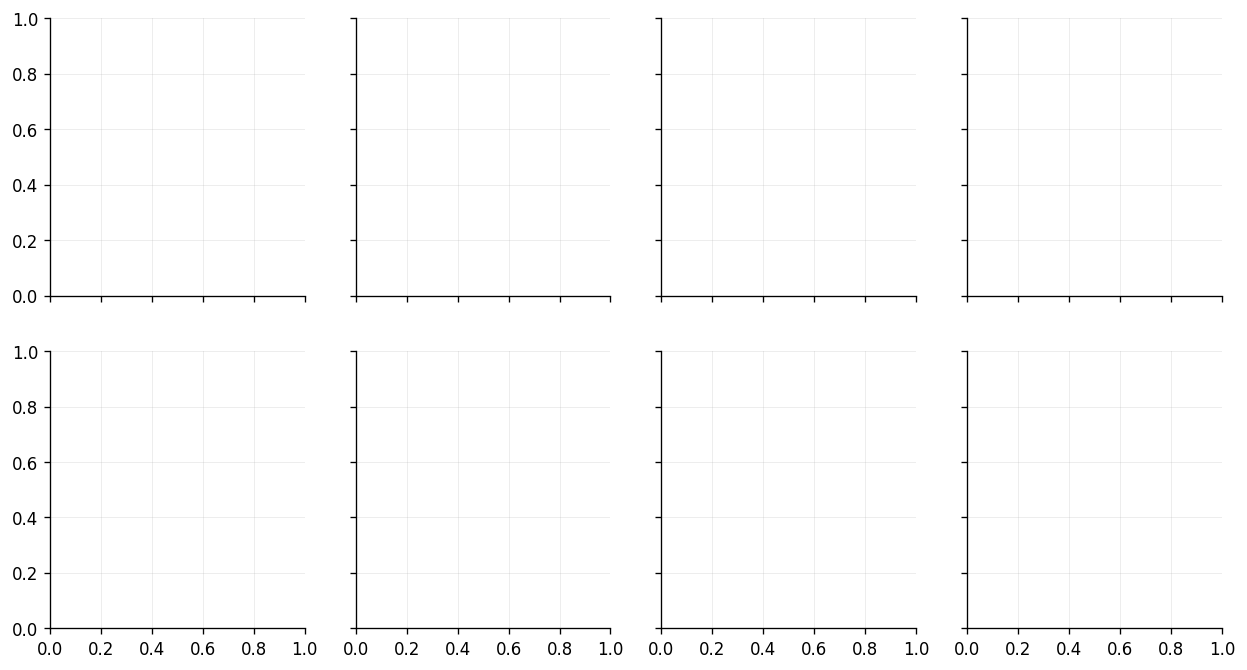

In [15]:
# --- 5.2 -- the flow field: what each frozen-input map does to all of hidden space -----------
# One column per input. Arrows are h -> gru_step(h) - h: where the update pushes each point.
# Top row the solved network, bottom row the trained one, same axes.
GRID = 17
lim  = 1.06
gx = np.linspace(-lim, lim, GRID)
XX, YY = np.meshgrid(gx, gx)

fig, axes = plt.subplots(2, A * Y, figsize=(3.15 * A * Y, 6.6), sharex=True, sharey=True)
for row, (Pm, Em, nm, col) in enumerate([(SOLVED[H_STAR], EMB[H_STAR], "solved", C_SOLVED),
                                         (TRAINED[H_STAR], None,       "trained", C_TRAINED)]):
    k = 0
    for a in range(A):
        for y in range(Y):
            ax = axes[row, k]; k += 1
            x = encode_input(a, y, A, Y)
            U = np.zeros_like(XX); V = np.zeros_like(YY)
            for i in range(GRID):
                for j in range(GRID):
                    hn, _ = gru_step(np.array([XX[i, j], YY[i, j]]), x, Pm)
                    U[i, j] = hn[0] - XX[i, j]; V[i, j] = hn[1] - YY[i, j]
            mag = np.hypot(U, V)
            ax.quiver(XX, YY, U, V, mag, cmap="viridis", scale=9, width=0.005,
                      alpha=0.9, pivot="mid")
            # star only ISOLATED attractors. Where the update gate is fully closed the map is
            # the identity over a region, every point of it is a fixed point, and marking one
            # would invent a structure that is not there.
            for h in input_map_fixed_points(Pm, a, y):
                if np.max(np.abs(jacobian_spectrum(Pm, h, a, y))) < 1 - 1e-4:
                    ax.plot(h[0], h[1], "*", ms=15, color=col, mec="k", mew=0.7, zorder=6)
            if Em is not None:
                for m in range(M):
                    ax.plot(Em[0, m], Em[1, m], "o", ms=9, mfc="none", mec=C_STATE[m], mew=2.2, zorder=7)
                    ax.annotate(f"e_{m}", (Em[0, m], Em[1, m]), textcoords="offset points",
                                xytext=(7, 6), fontsize=8, color=C_STATE[m])
            ax.plot(0, 0, "+", ms=9, color="0.3", mew=1.4, zorder=5)
            ax.set_title(f"{nm}: {ACT_NAME[a]}, {OBS_NAME[y]}", fontsize=9)
            if row == 1: ax.set_xlabel("$h_1$", fontsize=9)
            if k == 1:   ax.set_ylabel("$h_2$", fontsize=9)
            ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
fig.suptitle(f"The update rule as a flow on hidden space, H={H_STAR}.  "
             f"rings = embedded FSC states,  stars = isolated fixed points,  + = session start (h=0)",
             fontsize=11.5, y=1.0)
plt.tight_layout(); plt.show()

print("Solved, winning columns: every arrow is VERTICAL. There is no horizontal component")
print("anywhere, and horizontal is the axis the memory and the readout live on (both rings sit on")
print("h2 = 0). The map holds the memory coordinate of every point in hidden space and only")
print("collapses the unused h2 direction toward zero. No star, because there is no isolated")
print("attractor: the whole h1 axis is fixed. That is §5.1c, drawn.")
print("Solved, losing columns: strong horizontal flow, and the requirement -- one step from a ring")
print("lands on the OTHER ring -- was verified numerically in §5.1a. The star marks where that map")
print("would end up under repetition, which is not the same point and is not asked for: the")
print("machine never receives the same losing input twice running.")
print("Trained: horizontal flow in every panel, including the winning ones where the rule says")
print("hold, converging on fixed points that are not at anything the FSC would recognize.")
print("\nThe solved network also uses only the h1 axis, which is §2.2's observation drawn: two")
print("memory states need one direction, and the second unit is left flat.")

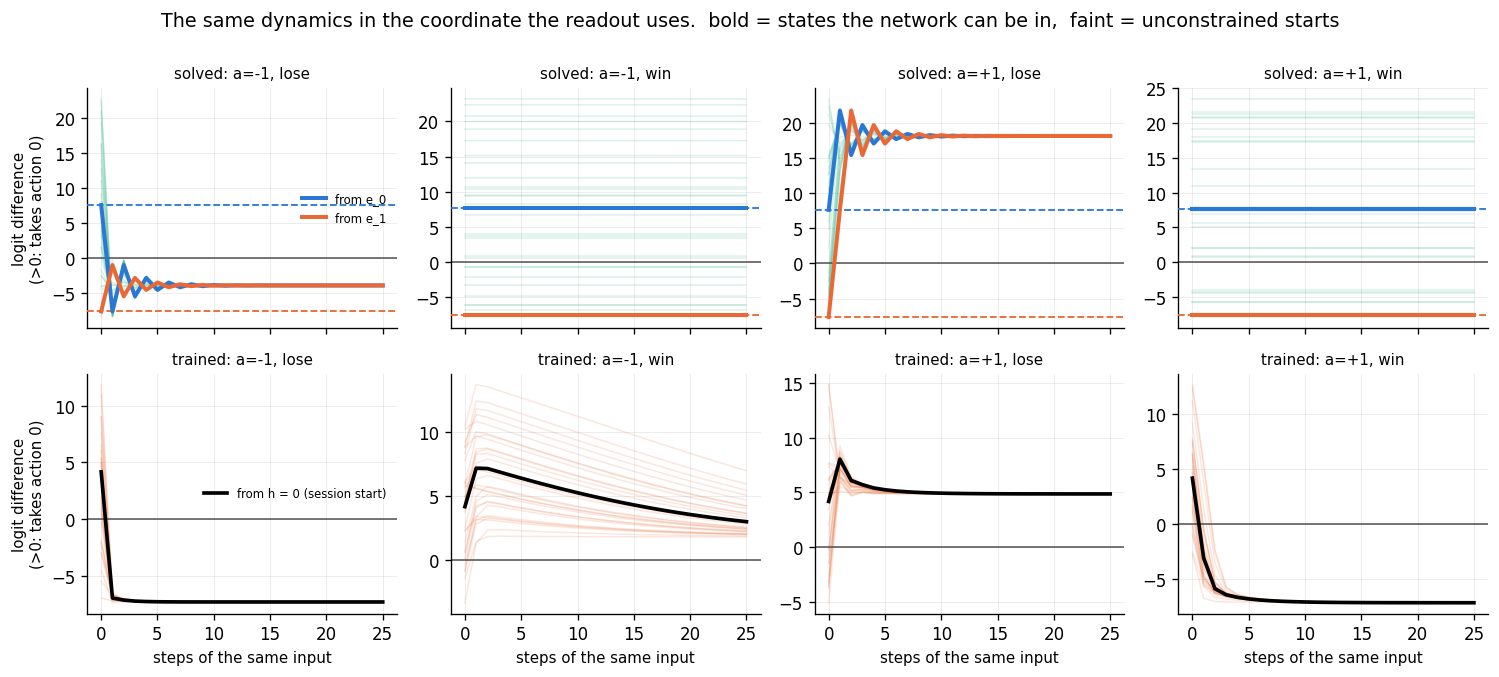

Follow the BOLD traces, which start from the states the network can actually be in.
Solved, winning columns: perfectly flat, each holding its own level, forever. That is
win-stay, and it is the whole of what the rule asks for here.
Solved, losing columns: read only the FIRST step, because that is the only one the machine
ever takes. It lands on the other state's dashed line exactly (§5.1a measures it at 1e-11).
From step 2 on the same losing input is being repeated, which the machine never does -- one
loss moves it to the state that plays the other arm -- so the trace wandering away from the
dashed line afterwards is the construction being unconstrained, not being wrong.

The faint traces start from points scattered through hidden space, which the network
never visits and which §2 imposes no requirement on. They do not land on the dashed lines,
and they are not supposed to: the construction is exact where the machine lives and says
nothing anywhere else. Showing them separately is the 

In [ ]:
# --- 5.3 -- the same dynamics read in logit coordinates -------------------------------------
# Hidden space is only interpretable through the readout, so project onto the quantity the
# readout actually uses: the logit difference d = (lin_W[0] - lin_W[1]) . h + (lin_b[0] - lin_b[1]).
# d > 0 means "will take action 0". Each trace is one random starting hidden state.
def logit_diff(P, h):
    return float((P["lin_W"][0] - P["lin_W"][1]) @ np.atleast_1d(h) + (P["lin_b"][0] - P["lin_b"][1]))

NSTEPS, NTRACE = 25, 30
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, A * Y, figsize=(3.15 * A * Y, 5.6), sharex=True)
for row, (Pm, Em, nm, col) in enumerate([(SOLVED[H_STAR], EMB[H_STAR], "solved", C_SOLVED),
                                         (TRAINED[H_STAR], None,       "trained", C_TRAINED)]):
    k = 0
    for a in range(A):
        for y in range(Y):
            ax = axes[row, k]; k += 1
            x = encode_input(a, y, A, Y)

            def trace(h0, **kw):
                h = np.asarray(h0, float).copy(); tr = [logit_diff(Pm, h)]
                for _ in range(NSTEPS):
                    h, _ = gru_step(h, x, Pm); tr.append(logit_diff(Pm, h))
                ax.plot(tr, **kw)

            # faint: starts scattered through hidden space. Nothing in §2 constrains these, so
            # they show what the construction happens to do, not what it guarantees.
            for h0 in rng.uniform(-1, 1, (NTRACE, Pm["H"])):
                trace(h0, color=col, alpha=0.16, lw=0.9, zorder=2)
            # bold: the states the network can actually BE in. For the solved network those are
            # the embedded states; h = 0 is one of them. The trained network has no such set,
            # so only its session start is marked.
            if Em is not None:
                for m in range(M):
                    trace(Em[:, m], color=C_STATE[m], lw=2.4, zorder=5,
                          label=f"from e_{m}" if k == 1 else None)
                    ax.axhline(logit_diff(Pm, Em[:, m]), color=C_STATE[m], ls="--", lw=1.1, zorder=4)
            else:
                trace(np.zeros(Pm["H"]), color="k", lw=2.2, zorder=5,
                      label="from h = 0 (session start)" if k == 1 else None)
            ax.axhline(0, color="0.3", lw=0.9)
            ax.set_title(f"{nm}: {ACT_NAME[a]}, {OBS_NAME[y]}", fontsize=9)
            if row == 1: ax.set_xlabel("steps of the same input", fontsize=9)
            if k == 1:
                ax.set_ylabel("logit difference\n(>0: takes action 0)", fontsize=9)
                ax.legend(fontsize=7, loc="center right")
fig.suptitle("The same dynamics in the coordinate the readout uses.  bold = states the network can be in,  "
             "faint = unconstrained starts", fontsize=11.5, y=1.0)
plt.tight_layout(); plt.show()

print("Follow the BOLD traces, which start from the states the network can actually be in.")
print("Solved, winning columns: perfectly flat, each holding its own level, forever. That is")
print("win-stay, and it is the whole of what the rule asks for here.")
print("Solved, losing columns: read only the FIRST step, because that is the only one the machine")
print("ever takes. It lands on the other state's dashed line exactly (§5.1a measures it at 1e-11).")
print("From step 2 on the same losing input is being repeated, which the machine never does -- one")
print("loss moves it to the state that plays the other arm -- so the trace wandering away from the")
print("dashed line afterwards is the construction being unconstrained, not being wrong.")
print("\nThe faint traces start from points scattered through hidden space, which the network")
print("never visits and which §2 imposes no requirement on. They do not land on the dashed lines,")
print("and they are not supposed to: the construction is exact where the machine lives and says")
print("nothing anywhere else. Showing them separately is the honest version of the picture.")
print("\nTrained: there is no such distinction to draw, because none of its states are pinned. Its")
print("traces move under every input, including the winning ones where the rule says hold, and")
print("settle at levels that correspond to no FSC state.")

## 6. The map between the two internal states, in both directions

The two models keep different things in memory: the FSC a spread over $M$ discrete states,
$\vec{p}_{\text{FSC}} \in [0,1]^M$, and the GRU a list of real numbers, $\vec{h} \in \mathbb{R}^H$.
Is one a translation of the other, both ways?

$$\vec{p}_{\text{FSC}} = A\vec{h} + \vec{b} \qquad\qquad \vec{h} = B\vec{p}_{\text{FSC}} + \vec{c}$$

**Affine** means multiply by a matrix, then add an offset. The offset is what lets the two coordinate
systems disagree about where zero is.

**This section measures; §2 built.** §2 solved for a network that did not exist yet. Here the
networks already exist and are never modified: for each one, a translation is fitted on top of its
hidden states by least squares from real sessions. That is a **linear probe**, and its *error* is the
result, not the matrix. §6.2 reports **max err**, the largest single miss and the column that
matters, alongside **$R^2$**, the conventional probe score. $R^2$ is what lets a trained network look
fine at 0.99 while its max err is 0.47.

The solved network needs no fitting: $E$ from §2 **is** the second map, with $B = E$ and
$\vec{c} = \vec{0}$, already verified trial by trial in §3.3. §6.2 fits it from data anyway so the
comparison with the trained nets is like for like. Contrast `fsc_tinyrnn_pipeline_ts.ipynb` §10.6,
where this same conversion was a fitted classifier scoring around 0.99; here it is neither fitted nor
a score.

So the open question is the other direction, and it has an exact answer.

### When the inverse exists

Recovering $\vec{p}$ from $\vec{h} = E\vec{p}$ affinely means finding $A, \vec{b}$ with
$A\vec{e}_m + \vec{b} = \vec{u}_m$ for every $m$. Stacked, that is

$$\begin{bmatrix} \vec{e}_0^\top & 1 \\ \vdots & \vdots \\ \vec{e}_{M-1}^\top & 1\end{bmatrix}
\begin{bmatrix} A^\top \\ \vec{b}^\top \end{bmatrix} = I_M$$

which is solvable exactly when that matrix has rank $M$: the embedded states must sit at genuinely
different places, none of them lying on the flat spanned by the others. That needs

$$\boxed{H \ge M - 1}$$

weaker than the obvious guess of $H = M$, because a spread over $M$ states has only $M - 1$ free
numbers once they are required to sum to 1. With $M = 2$ here, **one** hidden unit suffices, and §6.1
confirms the map is exact at $H = 1$.

### Why the offset is not optional

§1.2 pinned the start state to $h_0 = 0$, so $\vec{e}_{m_0} = \vec{0}$ and one column of $E$ is the
zero vector. A purely linear $\vec{p} = A\vec{h}$ would then send $\vec{h} = \vec{0}$ to
$\vec{p} = \vec{0}$, which is not a distribution at all. The offset carries exactly that, and §6.1
finds $\vec{b} = \vec{u}_{m_0}$, the one-hot of the start state. Drop the $h_0$ requirement and $E$
can be square and invertible, giving $A = E^{-1}$ and $\vec{b} = \vec{0}$; §6.4 does that and prices
what it costs.

In [ ]:
# --- 6.1 -- the map, straight from the construction -----------------------------------------
def affine_inverse_from_embedding(E):
    """Solve A e_m + b = u_m for every m. Returns (A, b, exact, rank), where `exact` is the
    largest violation at the embedded states and `rank` is the rank of [E^T | 1]."""
    Hh, Mm = E.shape
    S = np.hstack([E.T, np.ones((Mm, 1))])          # (M, H+1)
    with quiet_blas():
        Theta, *_ = np.linalg.lstsq(S, np.eye(Mm), rcond=None)
        rank = int(np.linalg.matrix_rank(S, tol=1e-9))
    A, b = Theta[:Hh].T, Theta[Hh]
    exact = float(np.abs(S @ Theta - np.eye(Mm)).max())
    return A, b, exact, rank

print("Forward map (FSC -> RNN):  h = B p + c   with B = E and c = 0, by construction.")
print("Inverse map (RNN -> FSC):  p = A h + b   solved from the embedded states.\n")
print(f"{'H':>3}  {'rank[E^T|1]':>12}  {'needs':>6}  {'invertible':>11}  "
      f"{'max error at e_m':>17}  {'b':>16}")
MAPS = {}
for H in H_LIST:
    E = EMB[H]
    Amat, bvec, exact, rk = affine_inverse_from_embedding(E)
    MAPS[H] = (Amat, bvec, exact, rk)
    print(f"{H:>3}  {rk:>12}  {M:>6}  {str(rk == M):>11}  {exact:>17.2e}  "
          f"{str(np.round(bvec, 6).tolist()):>16}")

print(f"\nThe rank is {M} at every size including H = 1, so the inverse is exact everywhere: the")
print(f"condition H >= M - 1 = {M-1} is met by all of them. And b comes out as the one-hot of the")
print(f"start state m={M0}, exactly as predicted, because e_{M0} = 0 forces A*0 + b = u_{M0}.\n")

H = H_STAR
Amat, bvec, _, _ = MAPS[H]
print(f"Written out at H = {H}:")
print(f"   p = A h + b   with A = {np.round(Amat, 6).tolist()},  b = {np.round(bvec, 6).tolist()}")
print(f"   h = B p + c   with B = {np.round(EMB[H], 6).tolist()},  c = {np.zeros(H).tolist()}")
print(f"\n   B is singular (det = {np.linalg.det(EMB[H]):.2e}) because its m={M0} column is the zero")
print( "   vector, so A is not B inverse and could not be. The pair is still an exact two-way map:")
comp = Amat @ EMB[H] + bvec[:, None]
print(f"   A B + b (should be the identity, column m -> u_m):\n{np.round(comp, 9)}")
print(f"   max deviation from I: {np.abs(comp - np.eye(M)).max():.2e}")

Forward map (FSC -> RNN):  h = B p + c   with B = E and c = 0, by construction.
Inverse map (RNN -> FSC):  p = A h + b   solved from the embedded states.

  H   rank[E^T|1]   needs   invertible   max error at e_m                 b
  1             2       2         True           4.44e-16        [1.0, 0.0]
  2             2       2         True           3.33e-16        [1.0, 0.0]
  3             2       2         True           5.55e-16       [1.0, -0.0]
  4             2       2         True           4.44e-16        [1.0, 0.0]

The rank is 2 at every size including H = 1, so the inverse is exact everywhere: the
condition H >= M - 1 = 1 is met by all of them. And b comes out as the one-hot of the
start state m=0, exactly as predicted, because e_0 = 0 forces A*0 + b = u_0.

Written out at H = 2:
   p = A h + b   with A = [[-1.058209, 0.0], [1.058209, -0.0]],  b = [1.0, 0.0]
   h = B p + c   with B = [[0.0, 0.944993], [-0.0, -0.0]],  c = [0.0, 0.0]

   B is singular (det = 7.13e-21) bec

In [ ]:
# --- 6.2 -- both maps fitted from data, held out, solved vs trained --------------------------
# Nothing above used data. Here both directions are FITTED by least squares on trials, in the
# way you would have to if you did not have the construction. Fit on even-numbered sessions,
# every number reported from the odd ones. Splitting by session, not by trial, stops
# neighbouring trials leaking across the split.
def paired_states(P, sessions):
    """(hidden vector, FSC belief) for the same trial of the same session."""
    Hs, Bs = [], []
    for s in sessions:
        Hs.append(rnn_states(P, s["actions"], s["observations"], A, Y))
        Bs.append(fsc_beliefs(FSC, s["actions"], s["observations"]))
    return np.concatenate(Hs), np.concatenate(Bs)

def fit_affine(X, Ytg):
    """Least-squares affine map X -> Ytg. Returns (W, c) with prediction X @ W + c."""
    Xa = np.hstack([X, np.ones((len(X), 1))])
    with quiet_blas():
        Th, *_ = np.linalg.lstsq(Xa, Ytg, rcond=None)
    return Th[:-1], Th[-1]

def r2(true, pred):
    ss = ((true - pred) ** 2).sum(); st = ((true - true.mean(0)) ** 2).sum()
    return float(1 - ss / st) if st > 0 else float("nan")

FIT_N = 400                                        # sessions used; 200 fit, 200 held out
sess_fit  = D["sessions"][0:FIT_N:2]
sess_test = D["sessions"][1:FIT_N:2]

print("Fitted on 200 sessions, reported on 200 held-out sessions.\n")
print(f"{'model':>14}   {'RNN -> FSC':^34}   {'FSC -> RNN':^24}")
print(f"{'':>14}   {'max err':>9} {'R2':>8} {'state right':>13}   {'max err':>9} {'R2':>12}")
MAPFIT = {}
for tag, MODELS in (("solved", SOLVED), ("trained", TRAINED)):
    for H in H_LIST:
        P = MODELS[H]
        Xtr, Btr = paired_states(P, sess_fit)
        Xte, Bte = paired_states(P, sess_test)
        Af, bf = fit_affine(Xtr, Btr)                        # h -> p
        Bf, cf = fit_affine(Btr, Xtr)                        # p -> h
        with quiet_blas():
            p_hat = Xte @ Af + bf
            h_hat = Bte @ Bf + cf
        acc = float((p_hat.argmax(1) == Bte.argmax(1)).mean())
        MAPFIT[(tag, H)] = dict(A=Af.T, b=bf, B=Bf.T, c=cf,
                                err_fwd=float(np.abs(p_hat - Bte).max()), r2_fwd=r2(Bte, p_hat),
                                acc=acc, err_bwd=float(np.abs(h_hat - Xte).max()),
                                r2_bwd=r2(Xte, h_hat))
        d = MAPFIT[(tag, H)]
        print(f"{tag+' H='+str(H):>14}   {d['err_fwd']:>9.2e} {d['r2_fwd']:>8.4f} "
              f"{acc:>12.4%}   {d['err_bwd']:>9.2e} {d['r2_bwd']:>12.4f}")

print("\nFor the solved networks the fitted map is exact on held-out data, in both directions, at")
print("every size. It is also the SAME map the construction gives without ever looking at data.")
print("Compared by what the maps DO to the embedded states, not entry by entry: the hidden states")
print("here span only one direction, so many different matrices act identically on them and an")
print("entrywise comparison would be comparing arbitrary choices rather than maps.")
for H in H_LIST:
    d = MAPFIT[("solved", H)]
    fwd = max(np.abs(d["A"] @ EMB[H][:, m] + d["b"] - np.eye(M)[m]).max() for m in range(M))
    bwd = max(np.abs(d["B"] @ np.eye(M)[m] + d["c"] - EMB[H][:, m]).max() for m in range(M))
    print(f"   H={H}: fitted map sends e_m -> u_m to {fwd:.2e}, and u_m -> e_m to {bwd:.2e}")

print("\nFor the trained networks neither direction is exact. Two cautions on reading that table.")
print("First, the 'state right' column is not the achievement it looks like HERE: this FSC's two")
print("states map one-to-one onto the two actions, so decoding the state from the hidden vector")
print("is the same problem as decoding the action, which §3.3 already showed both models agree on")
print("100% of the time. The column that carries information is 'max err', and it is 0.47 against")
print("the solved networks' 1e-8. Second, the FSC -> RNN direction is much worse than RNN -> FSC:")
print("knowing the memory state does not pin down the hidden vector, because the hidden vector is")
print("holding something the memory state does not encode.")

Fitted on 200 sessions, reported on 200 held-out sessions.

         model               RNN -> FSC                      FSC -> RNN       
                   max err       R2   state right     max err           R2


    solved H=1    3.05e-07   1.0000    100.0000%    2.39e-07       1.0000


    solved H=2    4.05e-08   1.0000    100.0000%    3.83e-08       1.0000


    solved H=3    2.12e-08   1.0000    100.0000%    3.04e-08       1.0000


    solved H=4    4.03e-08   1.0000    100.0000%    3.81e-08       1.0000


   trained H=1    4.67e-01   0.9898    100.0000%    8.46e-01       0.9898


   trained H=2    4.68e-01   0.9933    100.0000%    1.28e+00       0.6141


   trained H=3    3.81e-01   0.9961    100.0000%    1.17e+00       0.2858


   trained H=4    3.55e-01   0.9908    100.0000%    1.47e+00       0.6945

For the solved networks the fitted map is exact on held-out data, in both directions, at
every size. It is also the SAME map the construction gives without ever looking at data.
Compared by what the maps DO to the embedded states, not entry by entry: the hidden states
here span only one direction, so many different matrices act identically on them and an
entrywise comparison would be comparing arbitrary choices rather than maps.
   H=1: fitted map sends e_m -> u_m to 1.65e-08, and u_m -> e_m to 1.29e-08
   H=2: fitted map sends e_m -> u_m to 1.02e-09, and u_m -> e_m to 9.66e-10
   H=3: fitted map sends e_m -> u_m to 4.33e-10, and u_m -> e_m to 8.14e-10
   H=4: fitted map sends e_m -> u_m to 1.02e-09, and u_m -> e_m to 9.67e-10

For the trained networks neither direction is exact. Two cautions on reading that table.
First, the 'state right' column is not the achievement it looks like HERE: this FSC's two
states m

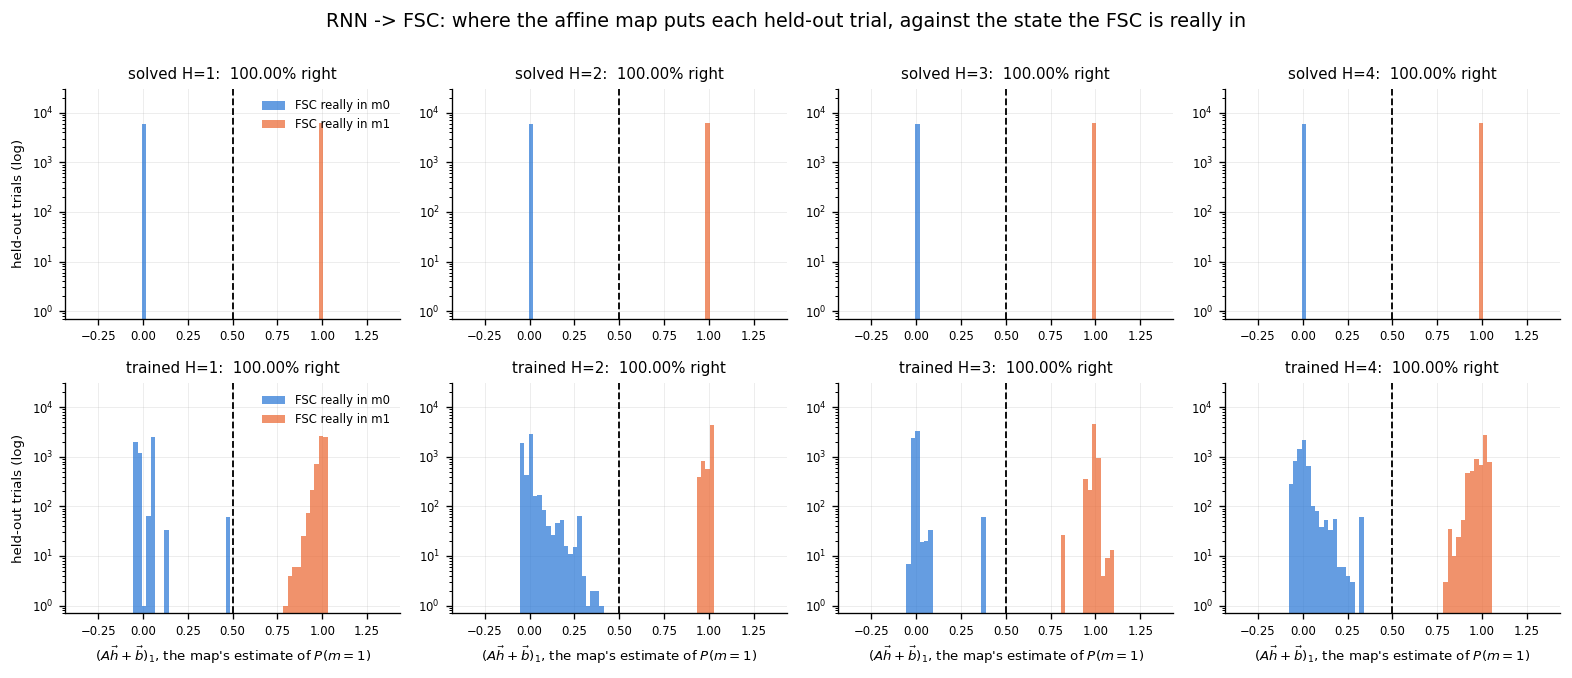

Solved: two spikes, at 0 and at 1, and nothing anywhere else. The map does not estimate
the FSC's state, it returns it.
Trained: two clouds. They are on the right sides of the boundary almost always, which is
why the accuracy is high, but they are spread, and the spread is the part of the hidden
state that the FSC's discrete memory has no slot for.


In [ ]:
# --- 6.3 -- what the map looks like: held-out trials on the map's own axis --------------------
# Each held-out trial placed on A h + b, colored by the FSC state it is really in. Two piles at
# the one-hot corners means the map is a genuine correspondence, not a threshold that happens
# to work.
fig, axes = plt.subplots(2, len(H_LIST), figsize=(3.3 * len(H_LIST), 5.6), squeeze=False)
for row, tag in enumerate(("solved", "trained")):
    for col, H in enumerate(H_LIST):
        ax = axes[row, col]
        P = (SOLVED if tag == "solved" else TRAINED)[H]
        Xte, Bte = paired_states(P, sess_test[:60])
        d = MAPFIT[(tag, H)]
        with quiet_blas():
            p_hat = Xte @ d["A"].T + d["b"]
        truth = Bte.argmax(1)
        bins = np.linspace(min(-0.35, p_hat[:, 1].min()), max(1.35, p_hat[:, 1].max()), 70)
        for m in range(M):
            ax.hist(p_hat[truth == m, 1], bins=bins, alpha=0.72, color=C_STATE[m],
                    label=f"FSC really in m{m}")
        ax.axvline(0.5, color="k", ls="--", lw=1.1)
        ax.set_yscale("log"); ax.set_ylim(0.7, 3e4)
        ax.set_title(f"{tag} H={H}:  {d['acc']:.2%} right", fontsize=9)
        if row == 1: ax.set_xlabel("$(A\\vec{h}+\\vec{b})_1$, the map's estimate of $P(m{=}1)$", fontsize=8)
        if col == 0:
            ax.set_ylabel("held-out trials (log)", fontsize=8); ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)
fig.suptitle("RNN -> FSC: where the affine map puts each held-out trial, against the state the FSC is really in",
             fontsize=11.5, y=1.0)
plt.tight_layout(); plt.show()

print("Solved: two spikes, at 0 and at 1, and nothing anywhere else. The map does not estimate")
print("the FSC's state, it returns it.")
print("Trained: two clouds. They are on the right sides of the boundary almost always, which is")
print("why the accuracy is high, but they are spread, and the spread is the part of the hidden")
print("state that the FSC's discrete memory has no slot for.")

### 6.4 The square, invertible case

Everything above keeps the $h_0 = 0$ requirement, which forces $\vec{e}_{m_0} = \vec{0}$ and
therefore an affine inverse with $\vec{b} \ne \vec{0}$. Drop that requirement and the embedding is
free, so it can be *chosen* rather than solved for. Set $E = sI$ with $H = M$ and the translation
becomes as simple as a translation can be,

$$\vec{h} = s\,\vec{p}_{\text{FSC}}, \qquad \vec{p}_{\text{FSC}} = s^{-1}\vec{h},$$

with $A = E^{-1}$ and $\vec{b} = \vec{c} = \vec{0}$: the hidden state literally *is* the FSC's state
vector, rescaled.

**Why $s < 1$ and not $s = 1$.** A GRU's hidden state is a blend of its previous value and a
$\tanh$, and $\tanh$ never actually reaches $\pm 1$. So the hidden state can approach 1 but never
touch it, which makes $E = I$ unreachable while $E = 0.9I$ is fine.

**The cost is the first trial.** With $\vec{e}_{m_0} = s\,\vec{u}_{m_0} \ne \vec{0}$ and the network
still starting at $\vec{h} = \vec{0}$, the network opens each session in a state that stands for
nothing, and joins the machine only once the first observation arrives. The two cells below solve it
both ways and price the trade.

In [ ]:
# --- 6.4 -- solve again with the embedding PRESCRIBED as a scaled identity -------------------
S_SCALE = 0.9                       # < 1: a GRU hidden state cannot reach +-1 exactly
E_SQUARE = S_SCALE * np.eye(M)
print(f"Prescribing E = {S_SCALE} * I  (H = M = {M}), and dropping the h0 requirement.\n")
P_sq, E_sq, res_sq = solve_gru_for_fsc(pi, g, rho, M, pin_h0=False, E_fixed=E_SQUARE, restarts=4)
print(f"\n   max requirement violation: {res_sq:.2e}")
print(f"   E   = {np.round(E_sq, 6).tolist()}      det = {np.linalg.det(E_sq):.4f}")
print(f"   A   = E^-1 = {np.round(np.linalg.inv(E_sq), 6).tolist()}")
print(f"   b   = c = 0")

e_trans = max(np.abs(gru_step(E_sq[:, m], encode_input(a, y, A, Y), P_sq)[0] - E_sq @ gn).max()
              for (m, a, y, gn) in TRANS)
print(f"\n   transitions replayed through gru_step: max error {e_trans:.2e}")
for m in range(M):
    print(f"   readout at e_{m} = {np.round(E_sq[:, m], 4).tolist()}: "
          f"{np.round(rnn_action_probs(E_sq[:, m], P_sq), 6).tolist()}  "
          f"(target {np.round(pi[m], 6).tolist()})")
print(f"   the network still starts at h = 0, which is not any e_m: "
      f"distance to nearest is {min(np.linalg.norm(E_sq[:, m]) for m in range(M)):.4f}")

ce_all, ce_first = ce_rnn(P_sq, SESS)
ce_pin, ce_pin_first = ce_rnn(SOLVED[M], SESS)
print(f"\n   Cost of dropping the h0 requirement, on the real sessions:")
print(f"      {'':>28}  {'CE / trial':>11}  {'CE on trial 0':>14}")
print(f"      {'E = 0.9 I, no h0 requirement':>28}  {ce_all:>11.5f}  {ce_first:>14.5f}")
print(f"      {'E solved, h0 requirement on':>28}  {ce_pin:>11.5f}  {ce_pin_first:>14.5f}")
print("\n   Both implement the machine exactly from trial 1 onward. They differ only on trial 0,")
print("   where the first has to guess and the second does not. Whether that matters is a")
print("   modelling choice, not a fact about GRUs: pick the square identity map if you want the")
print("   cleanest correspondence, pick the pinned embedding if you want the first trial right.")

Prescribing E = 0.9 * I  (H = M = 2), and dropping the h0 requirement.



     restart 0: max requirement violation 4.01e-10   ||params||  25.93


     restart 1: max requirement violation 6.07e-10   ||params||  26.10


     restart 2: max requirement violation 6.06e-10   ||params||  26.11


     restart 3: max requirement violation 1.01e-10   ||params||  26.69

   max requirement violation: 4.01e-10
   E   = [[0.9, 0.0], [0.0, 0.9]]      det = 0.8100
   A   = E^-1 = [[1.111111, 0.0], [0.0, 1.111111]]
   b   = c = 0

   transitions replayed through gru_step: max error 4.01e-10
   readout at e_0 = [0.9, 0.0]: [0.9995, 0.0005]  (target [1.0, 0.0])
   readout at e_1 = [0.0, 0.9]: [0.0005, 0.9995]  (target [0.0, 1.0])
   the network still starts at h = 0, which is not any e_m: distance to nearest is 0.9000



   Cost of dropping the h0 requirement, on the real sessions:
                                     CE / trial   CE on trial 0
      E = 0.9 I, no h0 requirement      0.00944         0.69312
       E solved, h0 requirement on      0.00050         0.00050

   Both implement the machine exactly from trial 1 onward. They differ only on trial 0,
   where the first has to guess and the second does not. Whether that matters is a
   modelling choice, not a fact about GRUs: pick the square identity map if you want the
   cleanest correspondence, pick the pinned embedding if you want the first trial right.


In [ ]:
# --- 6.5 -- the conditions, swept -------------------------------------------------------------
# The claim in the §6 preamble is that exactness of the inverse map depends on the RANK of the
# embedding, needing H >= M - 1, and on nothing else. Tested directly by trying every H and by
# deliberately breaking the rank.
print(f"M = {M} memory states, so the stated condition is H >= M - 1 = {M-1}.\n")
print(f"{'case':>34}  {'H':>3}  {'rank[E^T|1]':>12}  {'inverse exact?':>15}  {'max err':>10}")
for H in H_LIST:
    Amat, bvec, exact, rk = MAPS[H]
    print(f"{'solved, h0 pinned':>34}  {H:>3}  {rk:>12}  {str(exact < 1e-8):>15}  {exact:>10.2e}")
Asq, bsq, exsq, rksq = affine_inverse_from_embedding(E_sq)
print(f"{'solved, E = 0.9 I, h0 free':>34}  {M:>3}  {rksq:>12}  {str(exsq < 1e-8):>15}  {exsq:>10.2e}")

E_bad = np.zeros((2, M))                       # both states at the same point: rank collapses
E_bad[:, :] = np.array([[0.5], [0.2]])
Ab, bb, exb, rkb = affine_inverse_from_embedding(E_bad)
print(f"{'degenerate: all states co-located':>34}  {2:>3}  {rkb:>12}  {str(exb < 1e-8):>15}  {exb:>10.2e}")

print("\nAnd the same question asked of the maps FITTED from data rather than constructed. The")
print("solved rows are not at 1e-16 here because a 200-trial replay accumulates round-off; they")
print("are at the noise floor of the replay, seven orders below the trained ones:")
print(f"{'case':>34}  {'H':>3}  {'':>12}  {'inverse exact?':>15}  {'max err':>10}")
for tag in ("solved", "trained"):
    for H in H_LIST:
        d = MAPFIT[(tag, H)]
        print(f"{tag + ', fitted from data':>34}  {H:>3}  {'':>12}  "
              f"{str(d['err_fwd'] < 1e-5):>15}  {d['err_fwd']:>10.2e}")

print("\nSo the condition behaves as stated. Exactness is a property of where the memory states")
print("sit in hidden space, not of matching M to H: H = 1 carries M = 2 states exactly, and a")
print("rank-collapsed embedding fails at any H. Adding hidden units beyond M - 1 adds directions")
print("the map ignores, which is visible in the solved embeddings of §2.2 as columns of zeros.")
print("\nWhat the trained networks lack is not capacity. It is that their hidden states do not")
print("sit at M points at all: they occupy a spread region whose shape carries information the")
print("FSC has no state for, which is exactly the leftover §6.3's clouds show and the thing")
print("that goes wrong off the data manifold in `rnn_offmanifold_finding.ipynb`.")

M = 2 memory states, so the stated condition is H >= M - 1 = 1.

                              case    H   rank[E^T|1]   inverse exact?     max err
                 solved, h0 pinned    1             2             True    4.44e-16
                 solved, h0 pinned    2             2             True    3.33e-16
                 solved, h0 pinned    3             2             True    5.55e-16
                 solved, h0 pinned    4             2             True    4.44e-16
        solved, E = 0.9 I, h0 free    2             2             True    4.44e-16
 degenerate: all states co-located    2             1            False    5.00e-01

And the same question asked of the maps FITTED from data rather than constructed. The
solved rows are not at 1e-16 here because a 200-trial replay accumulates round-off; they
are at the noise floor of the replay, seven orders below the trained ones:
                              case    H                 inverse exact?     max err
          solved, fi

In [ ]:
# --- 7.1 -- consolidated summary ---------------------------------------------------------------
print(f"{'':>16}  {'CE/trial':>9}  {'WS rate':>8}  {'LS rate':>8}  "
      f"{'P(stay) at k=80':>16}  {'RNN->FSC err':>13}  {'FSC->RNN err':>13}")
sw, sl = rates_from_matrix(TM["FSC"])
c, _ = ce_fsc(SESS)
print(f"{'fitted FSC':>16}  {c:>9.5f}  {sw:>8.4f}  {sl:>8.4f}  "
      f"{fsc_probe(0, WIN)[KMAX]:>16.4f}  {'(is the FSC)':>13}  {'(is the FSC)':>13}")
for tag, MODELS in (("solved", SOLVED), ("trained", TRAINED)):
    for H in H_LIST:
        P = MODELS[H]
        sw, sl = rates_from_matrix(TM[f"{tag} H={H}"])
        c, _ = ce_rnn(P, SESS)
        d = MAPFIT[(tag, H)]
        print(f"{tag+' H='+str(H):>16}  {c:>9.5f}  {sw:>8.4f}  {sl:>8.4f}  "
              f"{rnn_probe(P, 0, WIN)[KMAX]:>16.4f}  "
              f"{d['err_fwd']:>13.2e}  {d['err_bwd']:>13.2e}")
print("\nColumns 1 to 3 are on-manifold and separate nothing: every model reproduces the behavior.")
print("Columns 4 to 6 are the ones that do. The last two are the held-out affine map's largest")
print("error in each direction (§6.2); the solved networks sit at the accumulated round-off of a")
print("200-trial replay, the trained ones four hundred thousand times higher.")

                   CE/trial   WS rate   LS rate   P(stay) at k=80   RNN->FSC err   FSC->RNN err


      fitted FSC    0.00000    1.0000    1.0000            1.0000   (is the FSC)   (is the FSC)


      solved H=1    0.00050    0.9995    0.9995            0.9995       3.05e-07       2.39e-07
      solved H=2    0.00050    0.9995    0.9995            0.9995       4.05e-08       3.83e-08
      solved H=3    0.00050    0.9995    0.9995            0.9995       2.12e-08       3.04e-08
      solved H=4    0.00050    0.9995    0.9995            0.9995       4.03e-08       3.81e-08
     trained H=1    0.00343    0.9980    0.9980            0.9996       4.67e-01       8.46e-01
     trained H=2    0.00102    0.9995    0.9984            0.8580       4.68e-01       1.28e+00
     trained H=3    0.00227    0.9987    0.9984            0.9996       3.81e-01       1.17e+00


     trained H=4    0.00029    0.9999    0.9998            0.9190       3.55e-01       1.47e+00

Columns 1 to 3 are on-manifold and separate nothing: every model reproduces the behavior.
Columns 4 to 6 are the ones that do. The last two are the held-out affine map's largest
error in each direction (§6.2); the solved networks sit at the accumulated round-off of a
200-trial replay, the trained ones four hundred thousand times higher.


## 7. What this establishes

Read against the numbers printed above.

1. **A GRU can hold the rule exactly, at every size tested including one hidden unit.** §2 solves
   for weights whose largest requirement violation is under $10^{-8}$, and about $6 \times 10^{-10}$
   at $H \ge 2$; $H = 1$ is the loosest at $8 \times 10^{-9}$. §3 replays them through the untouched
   numpy GRU to confirm it. The drift documented in `rnn_offmanifold_finding.ipynb` is therefore not
   a capacity limit of the architecture. It is something about how the weights were arrived at.

2. **The solved network is the controller, not an approximation of it.** Over 1000 real sessions its
   hidden state sits on the embedding of the FSC's memory state with a mean error of $10^{-9}$ per
   trial and a worst single trial of $4 \times 10^{-8}$ ($3 \times 10^{-7}$ at $H = 1$), and it
   picks the same action on 100% of trials (§3.3). That is a stronger statement than matching
   behavior: the two models agree because they are the same machine in different coordinates.

3. **The probe that broke training returns a flat line** (§4.4), and §5 says why in mechanical
   terms. The solve implemented "win-stay" by **closing the update gate**: under a winning input the
   map is the identity, with leading eigenvalue 1 to six places or better and displacement along the
   readout direction of $10^{-5}$ or less anywhere in hidden space, falling to $10^{-8}$ on one of
   the two winning maps (§5.1a, §5.1c). Nothing drifts because nothing moves it. That is stronger
   than a stable attractor, which at radius 0.999 would still creep, and creeping is precisely what
   the trained networks do: three of their four frozen-input maps are strict contractions toward a
   fixed point the FSC would not recognize, and the fourth has none inside the reachable box at all,
   so it pushes the state at the boundary instead of resting (§5.1b). Under losing inputs the solved
   maps are genuinely attracting, so the switch is self-correcting. Win-stay/lose-shift comes out as
   hold/reset. The ceiling at $1 - \texttt{conf}/2 = 0.9995$ is the cap §2 chose, not a decay.

4. **On-manifold measurements cannot see any of this.** Cross-entropy, the action transition matrix,
   and the win-stay/lose-shift rates put the solved network, the trained networks and the FSC within
   a few thousandths of each other (§4.1 to §4.3, and the summary table's first three columns).
   Every separation in this notebook comes from a measurement taken off the data manifold or from
   the internal state directly.

5. **The map between the two internal states is exact in both directions, and the condition for it
   is a rank condition.** $\vec{h} = E\vec{p}$ holds by construction; $\vec{p} = A\vec{h} + \vec{b}$
   is solvable exactly if and only if the embedded states are affinely independent, which requires
   $H \ge M - 1$ and nothing more (§6.1, §6.5). $H = 1$ carries $M = 2$ states exactly, and a
   rank-collapsed embedding fails at any $H$. Matching $H$ to $M$ is not the requirement it looks
   like.

6. **The offset is forced, and dropping it is a modelling choice with a price.** Because tinyRNN
   starts every session at $h_0 = 0$ and one memory state has to live there, $E$ has a zero column
   and the inverse must be affine rather than linear (§6.1). Prescribing $E = 0.9I$ instead gives
   the fully symmetric $\vec{h} = 0.9\,\vec{p}$, $\vec{p} = \vec{h}/0.9$ with no offset either way,
   at the cost of the first trial of every session: cross-entropy on trial 0 goes from 0.0005 to
   0.69, which is a coin flip (§6.4). Both are exact machines from trial 1 onward.

7. **The trained networks fail the map, not the behavior.** Their fitted affine map recovers the
   FSC's state by argmax on essentially every trial, reproducing the pipeline notebook's §10.6
   converter result, while carrying real reconstruction error in both directions: about 0.4 going
   RNN $\to$ FSC and 0.8 to 1.5 going FSC $\to$ RNN, against $10^{-8}$ for the solved networks
   (§6.2, §6.3). Their hidden states do not sit at $M$ points; they occupy a spread region, and the
   spread is information the discrete memory has no slot for.

### What this does not establish

- The construction is **not unique**, and no claim is made that it is minimal, canonical, or the
  one training would find if it worked. §2 returns the smallest-weight solution among the random
  starts it tried, which is a preference, not a proof.
- It is **exact but not robust**. The held states are neutral, not attracting (§5.1a), so nothing
  restores the hidden state if it is perturbed. A trained network's contraction is what buys
  robustness, and it is the same property that causes the drift. The sharpest case: start the solved
  network in the state that plays arm $-1$ and tell it "you played arm $+1$ and won". No requirement
  covers that, so it simply holds, reporting $P(\text{stay on }{+1}) = 0.0005$ flat. The trained
  networks land on the sensible answer instead, but only because they drift there. That is a
  statement about error correction, not about win-stay, which is why §4.4 starts every model in a
  state that plays the arm it probes.

- It says nothing about **why gradient descent misses it**. The solved weights exist in the same
  parameter space training searched. Whether they are unreachable, merely unrewarded on this
  data, or reachable with a longer budget is open. One relevant fact sits outside this notebook:
  the committed fits were stopped by the 2000-epoch cap with validation loss still falling and
  the best epoch being the last one in every run, so those networks had not converged.
- The worked machine is **deterministic**, with $M = 2$, and the construction depends on that
  more than it looks. Its belief sits on a memory state on 100% of trials, so pinning the $M$
  states pins the whole trajectory. `analytical_rnn_fsc_rwsls.ipynb` runs this same solver on a
  stochastic controller, where the belief is pure on 18% of trials: it still solves to machine
  precision and is no longer the controller. The solver runs unmodified on a stochastic $\pi$;
  what it returns is not what it returns here.

### Where to take it next

The natural test is a machine that actually needs its memory: $M \ge 3$ with states that cannot
be read off the last trial. There the $H \ge M - 1$ condition becomes a real constraint rather
than one that every size satisfies, and the question of whether training finds the solved
solution becomes worth asking with something at stake.